<a href="https://colab.research.google.com/github/shaloy-lewis/Car_Price_Prediction/blob/main/RR_Car_Price_Prediction_Shaloy_Lewis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Vehicle Prices Using Regression Models

## **Objectives**  
The primary goal of this project is to develop a robust regression model to predict used car prices for a reseller based on various listed features and specifications. In addition to predicting prices, the project focuses on identifying feature importance and mitigating overfitting through the application of regularisation techniques.

There can be several business objectives for this, such as:

* **Price Prediction**: Model car prices based on features like mileage, fuel type, and performance.
* **Market Analysis**: Explore trends and preferences in the used car market, by type, region, or other metrics.
* **Feature Importance**: Identify the most important factors influencing car prices (e.g., fuel type, mileage, age).

### **Tasks Overview**
The data pipeline for this task involves the following steps:  
1. **Dataset Overview**   
2. **Data Preprocessing**
3. **Data Visualisation & Exploration**
4. **Model Building**
3. **Regularisation**

## **1 Data Understanding**

| **Variable** | **Description** |
--------|--------------|
| `make_model` | The brand and model of the vehicle (e.g., 'Audi A1'). |
| `body_type` | The body style of the vehicle, such as Sedan, Compact, or Station Wagon. |
| `price`  | The listed price of the car in currency. |
| `vat`  | Indicates the VAT status for the vehicle's price (e.g., VAT deductible, Price negotiable). |
| `km` | The total mileage (in kilometers) of the vehicle, indicating its usage. |
| `Type` | Condition of the vehicle, whether it's 'Used' or 'New'.|
| `Fuel` | Type of fuel the vehicle uses, such as 'Diesel', 'Benzine', etc. |
| `Gears` | The number of gears in the vehicle's transmission. |
| `Comfort_Convenience` | Comfort and convenience features, such as 'Air conditioning', 'Leather steering wheel', 'Cruise control', and more. |
| `Entertainment_Media` | Media features available in the vehicle, including 'Bluetooth', 'MP3', 'Radio', etc. |
| `Extras` | Additional features like 'Alloy wheels', 'Sport suspension', etc.|
| `Safety_Security` | Safety features like 'ABS', 'Airbags', 'Electronic stability control', 'Isofix', etc.  |
| `age` | Age of the car (calculated based on the model year). |
| `Previous_Owners`| The number of previous owners the car has had. |
| `hp_kW` | Engine power in kilowatts (kW), indicating the performance capacity of the engine.|
| `Inspection_new` | Indicates whether the car has recently undergone an inspection (1 for yes, 0 for no). |
| `Paint_Type`| The type of paint on the car, such as 'Metallic', 'Matte', etc. |
| `Upholstery_type` | The material used for the interior upholstery, such as 'Cloth', 'Leather', etc.|
| `Gearing_Type` | The type of transmission the car uses, either 'Automatic' or 'Manual'. |
| `Displacement_cc` | The engine displacement in cubic centimeters (cc), indicating the size of the engine.|
| `Weight_kg` | The total weight of the vehicle in kilograms.|
| `Drive_chain` | The type of drivetrain, indicating whether it's 'Front' or 'Rear' wheel drive. |
| `cons_comb`  | The combined fuel consumption in liters per 100 kilometers.|

### **1.1 Data Loading**

**Importing Necessary Libraries**

In [445]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import scipy.stats as stats

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.linear_model import Lasso, Ridge
from statsmodels.stats.outliers_influence import variance_inflation_factor

#### **1.1.1**
Load the dataset

In [446]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [447]:
# Load the data
df = pd.read_csv('/content/drive/MyDrive/Upgrad/datasets/Car_Price_Prediction/Car_Price_data.csv')

In [448]:
df.head()

,make_model,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,...,Previous_Owners,hp_kW,Inspection_new,Paint_Type,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb
0,Audi A1,Sedans,15770,VAT deductible,56013.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,2.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1220.0,front,3.8
1,Audi A1,Sedans,14500,Price negotiable,80000.0,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Hil...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,141.0,0,Metallic,Cloth,Automatic,1798.0,1255.0,front,5.6
2,Audi A1,Sedans,14640,VAT deductible,83450.0,Used,Diesel,7.0,"Air conditioning,Cruise control,Electrical sid...","MP3,On-board computer",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1135.0,front,3.8
3,Audi A1,Sedans,14500,VAT deductible,73000.0,Used,Diesel,6.0,"Air suspension,Armrest,Auxiliary heating,Elect...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,0,Metallic,Cloth,Automatic,1422.0,1195.0,front,3.8
4,Audi A1,Sedans,16790,VAT deductible,16200.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1135.0,front,4.1


In [449]:
df.shape

(15915, 23)

## **2 Analysis and Feature Engineering** <font color =red> [35 marks] </font>



### **2.1 Preliminary Analysis and Frequency Distributions** <font color = red> [13 marks] </font>

#### **2.1.1** <font color =red> [1 marks] </font>
Check and fix missing values.

In [450]:
# Find the proportion of missing values in each column and handle if found
df.isna().sum()

,0
make_model,0
body_type,0
price,0
vat,0
km,0
Type,0
Fuel,0
Gears,0
Comfort_Convenience,0
Entertainment_Media,0


In [451]:
df['cons_comb'].value_counts()

,count
cons_comb,
4.00,1020
5.60,963
5.40,900
5.00,810
4.70,766
...,...
8.10,2
5.45,2
4.30,1


In [452]:
TARGET = ['price']
NUM_FEATURES = ['km', 'hp_kW', 'age', 'Previous_Owners', 'Displacement_cc', 'Weight_kg', 'cons_comb']
CAT_FEATURES = ['make_model', 'body_type', 'vat', 'Type', 'Fuel', 'Gears', 'Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security', 'Inspection_new', 'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Drive_chain']

In [453]:
df.columns

Index(['make_model', 'body_type', 'price', 'vat', 'km', 'Type', 'Fuel',
       'Gears', 'Comfort_Convenience', 'Entertainment_Media', 'Extras',
       'Safety_Security', 'age', 'Previous_Owners', 'hp_kW', 'Inspection_new',
       'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Displacement_cc',
       'Weight_kg', 'Drive_chain', 'cons_comb'],
      dtype='object')

In [454]:
len(NUM_FEATURES) + len(CAT_FEATURES) + len(TARGET) == df.shape[1]

True

**From the features, identify the target feature and numerical and categorical predictors. Select the numerical and categorical features carefully as they will be used in analysis.**

#### **2.1.2** <font color =red> [3 marks] </font>
Identify numerical predictors and plot their frequency distributions.

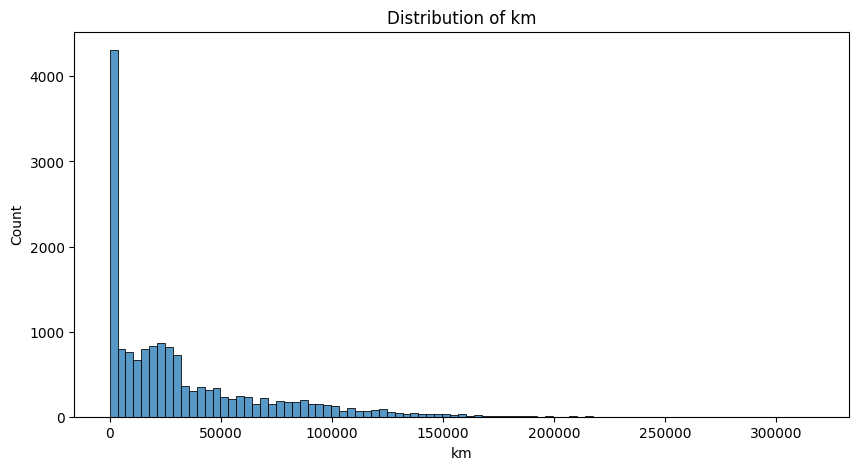

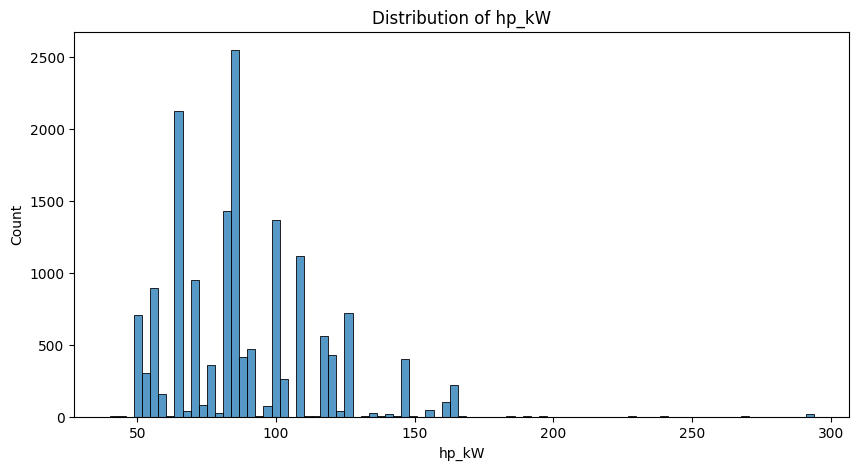

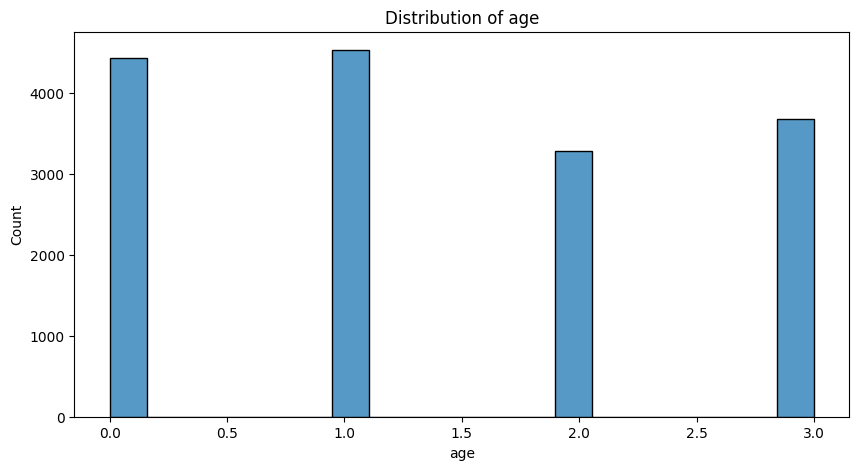

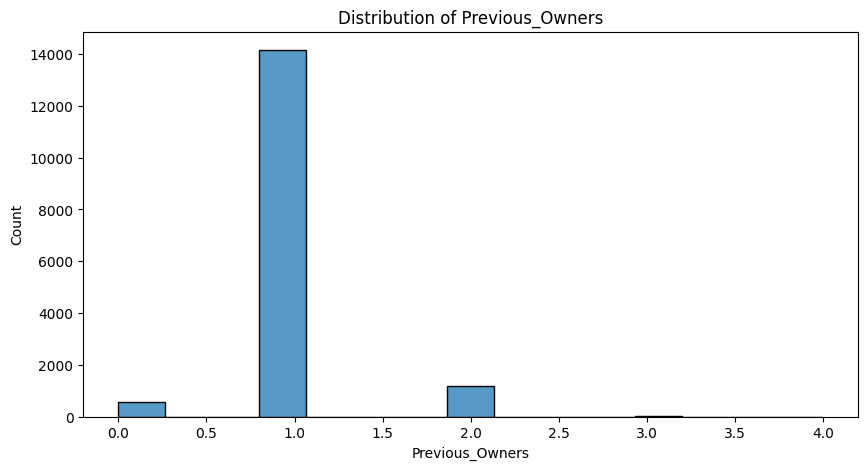

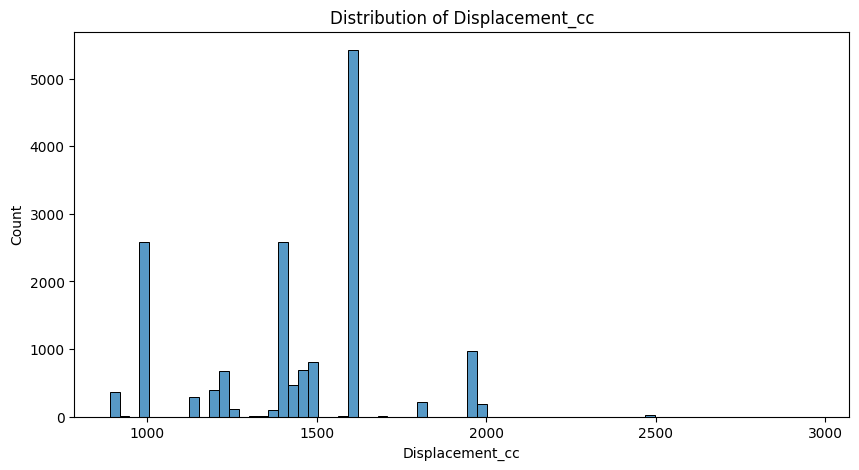

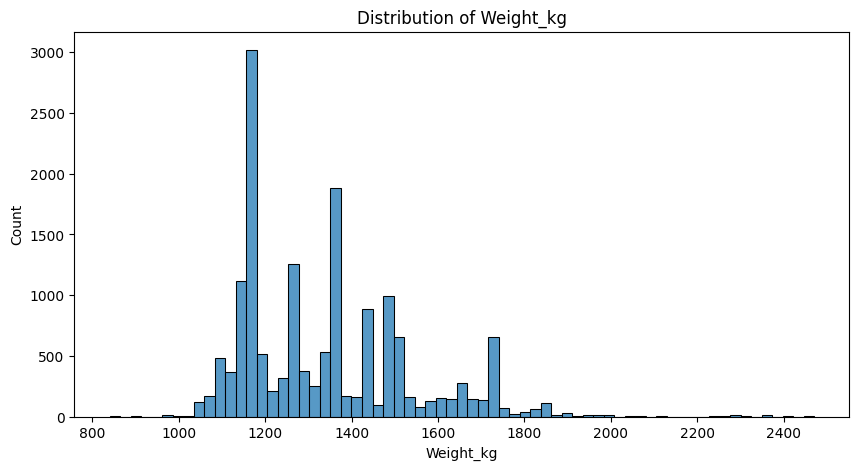

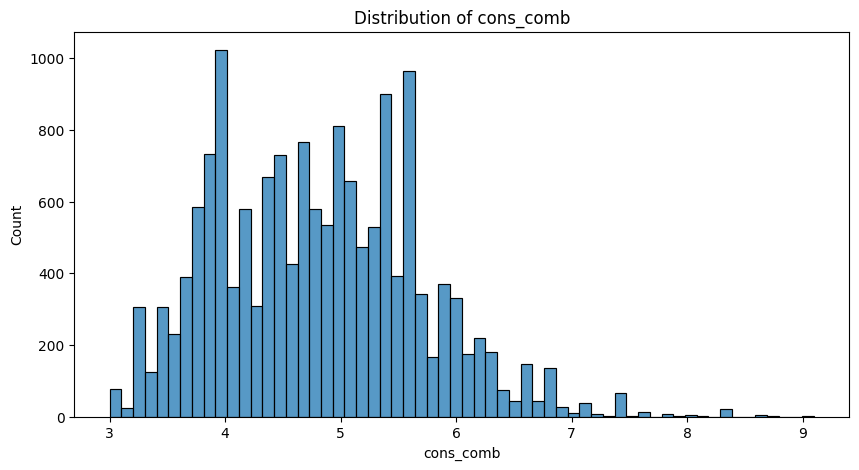

In [455]:
# Identify numerical features and plot histograms
for feature in NUM_FEATURES:
  plt.figure(figsize=(10,5))
  sns.histplot(df[feature])
  plt.title(f'Distribution of {feature}')
  plt.show()

#### **2.1.3** <font color =red> [3 marks] </font>
Identify categorical predictors and plot their frequency distributions.

In [456]:
for feature in CAT_FEATURES:
  print(f'Unique values in {feature}: {df[feature].nunique()}')

Unique values in make_model: 9
Unique values in body_type: 8
Unique values in vat: 2
Unique values in Type: 5
Unique values in Fuel: 4
Unique values in Gears: 4
Unique values in Comfort_Convenience: 6196
Unique values in Entertainment_Media: 346
Unique values in Extras: 659
Unique values in Safety_Security: 4442
Unique values in Inspection_new: 2
Unique values in Paint_Type: 3
Unique values in Upholstery_type: 2
Unique values in Gearing_Type: 3
Unique values in Drive_chain: 3


**Note**: Look carefully at the values stored in columns `["Comfort_Convenience", "Entertainment_Media", "Extras", "Safety_Security"]`.

Should they be considered categorical? Should they be dropped or handled any other way?

In [457]:
CAT_FEATURES_LOW_CARDINALITY = [
    feature for feature in CAT_FEATURES
    if df[feature].nunique() <= 10
]

In [458]:
CAT_FEATURES_LOW_CARDINALITY

['make_model',
 'body_type',
 'vat',
 'Type',
 'Fuel',
 'Gears',
 'Inspection_new',
 'Paint_Type',
 'Upholstery_type',
 'Gearing_Type',
 'Drive_chain']

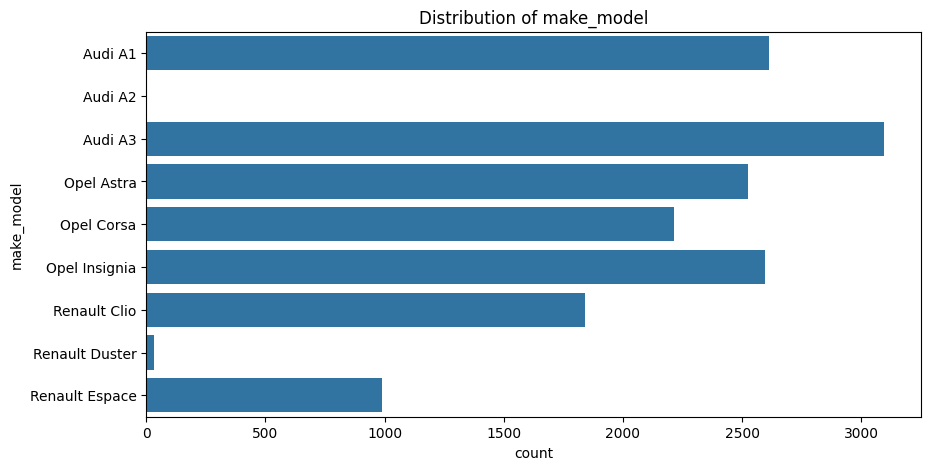

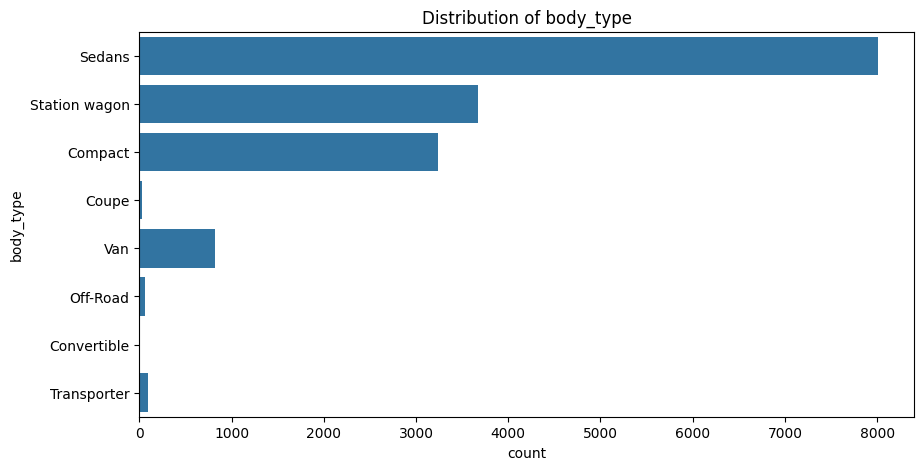

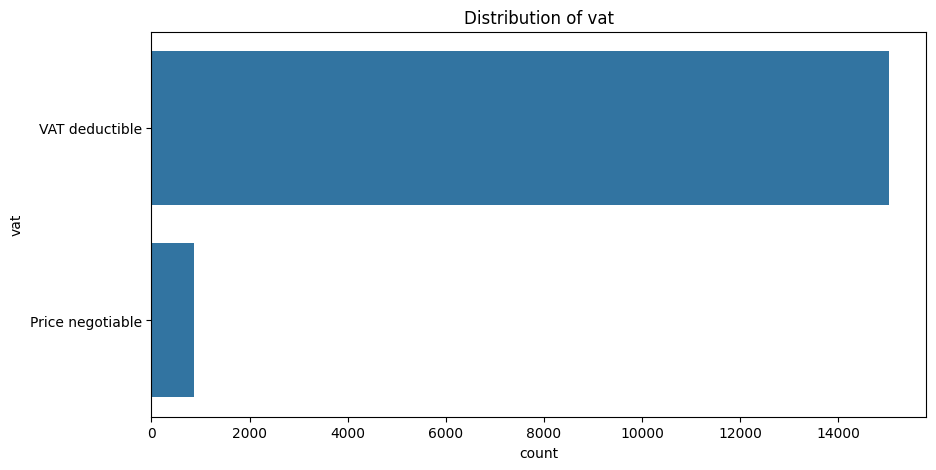

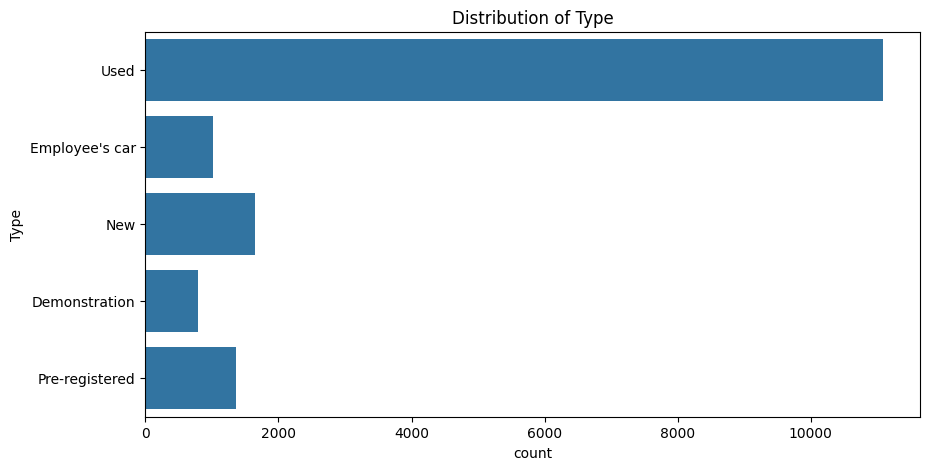

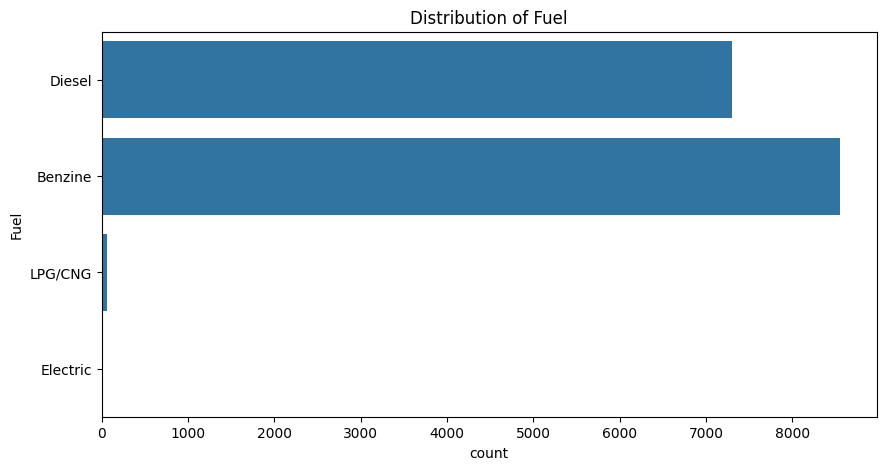

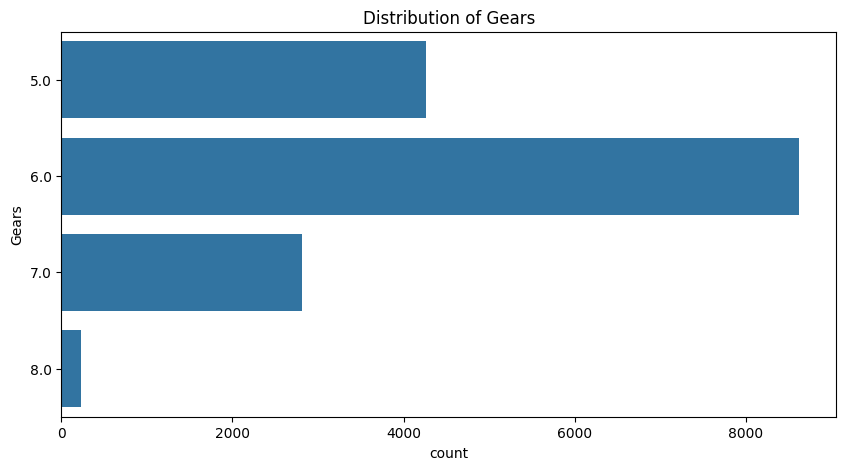

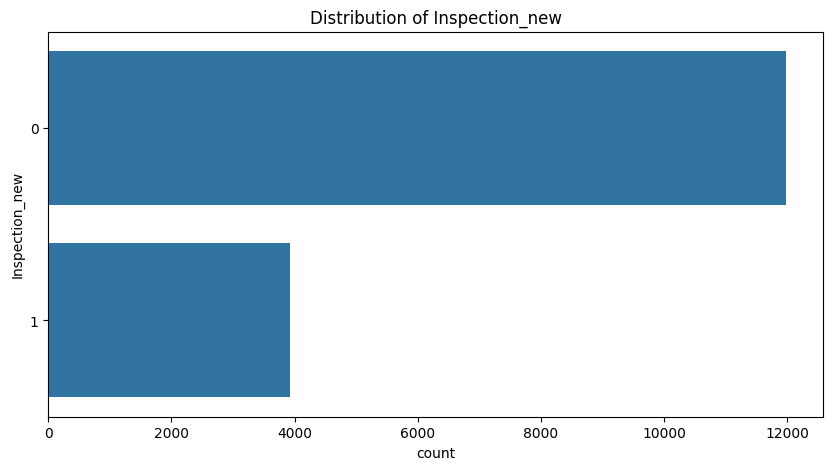

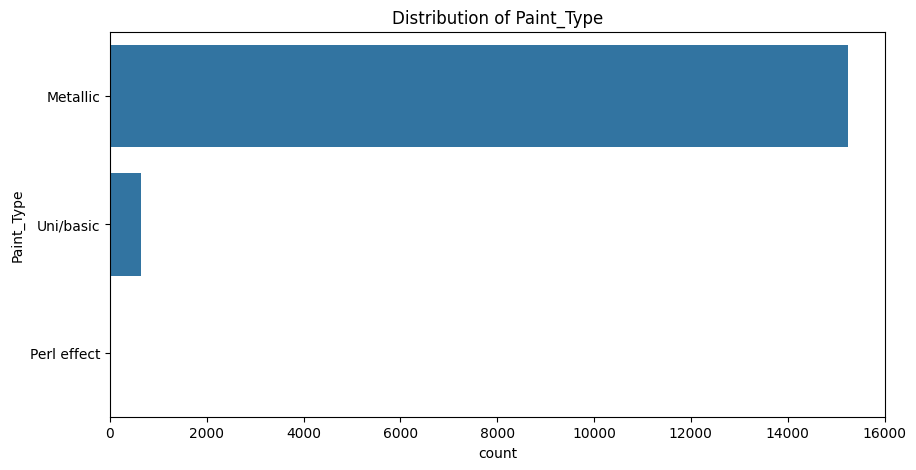

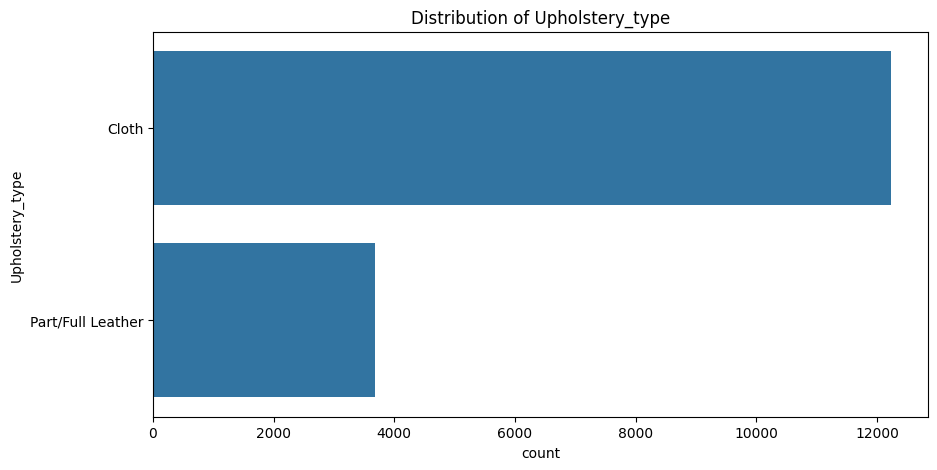

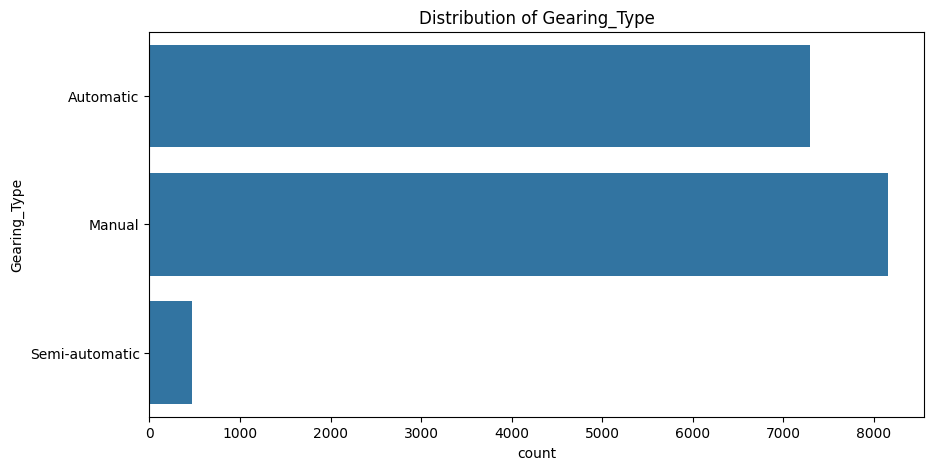

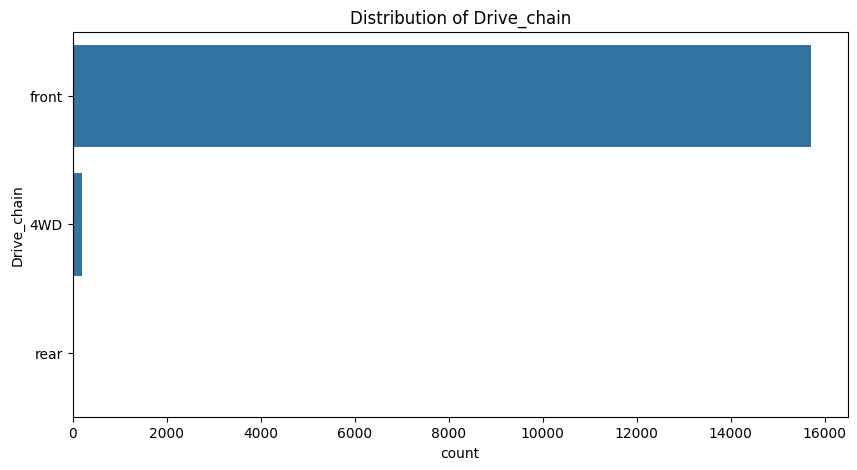

In [459]:
# Identify categorical columns and check their frequency distributions
for feature in CAT_FEATURES_LOW_CARDINALITY:
  plt.figure(figsize=(10,5))
  sns.countplot(y=df[feature])
  plt.title(f'Distribution of {feature}')
  plt.show()

#### **2.1.4** <font color =red> [3 marks] </font>
Fix columns with low frequency values and class imbalances.

Some information regarding values in the `Type` column that may help:
- *'Pre-registered'* cars are ones which have already been registered previously by the seller.
- *'New'* cars are not necessarily new cars, but new-like cars. These might also have multiple owners due to multiple pre-registrations as well.
- *'Employee's car'* are cars used by employees over a short period of time and small distance.
- *'Demonstration'* cars are used for trial purposes and also driven for a short time and distance.

Based on these, you can handle this particular column. For other columns, decide a strategy on your own.

In [460]:
df["Type"].value_counts()

,count
Type,
Used,11095
New,1649
Pre-registered,1364
Employee's car,1011
Demonstration,796


In [461]:
# Fix columns as needed

# 1. Consolidate make_model to brand names
make_model_map = {
    "Audi A1": "Audi",
    "Audi A2": "Audi",
    "Audi A3": "Audi",
    "Opel Astra": "Opel",
    "Opel Corsa": "Opel",
    "Opel Insignia": "Opel",
    "Renault Clio": "Renault",
    "Renault Duster": "Renault",
    "Renault Espace": "Renault"
}
df["make_model"] = df["make_model"].replace(make_model_map)

# 2. Group rare body types into "Other"
rare_body_types = ["Coupe", "Convertible", "Off-Road", "Transporter"]

df["body_type"] = df["body_type"].replace(
    rare_body_types, "Other"
)

# 3. Consolidate vehicle Type by usage
car_type_map = {
    "Employee's car": "Lightly Used",
    "Demonstration": "Lightly Used",
    "Pre-registered": "Nearly New",
    "New": "Nearly New"
}
df["Type"] = df["Type"].replace(car_type_map)

# 4. Consolidate rare fuel types into "Other"
df["Fuel"] = df["Fuel"].replace({
    "LPG/CNG": "Other",
    "Electric": "Other"
})

# 5. Consolidate gears >= 7 into "7+"
df["Gears"] = df["Gears"].apply(
    lambda x: "7+" if x >= 7 else str(int(x))
)

# 6. Consolidate Paint_Type into Metallic / Non-Metallic
df["Paint_Type"] = df["Paint_Type"].replace({
    "Uni/basic": "Non-Metallic",
    "Perl effect": "Non-Metallic"
})

# 7. Merge Semi-automatic with Automatic
df["Gearing_Type"] = df["Gearing_Type"].replace({
    "Semi-automatic": "Automatic"
})

# 8. Consolidate Drive_chain into Front / Non-Front
df["Drive_chain"] = df["Drive_chain"].replace({
    "4WD": "Non-Front",
    "rear": "Non-Front"
})

#### **2.1.5** <font color =red> [3 marks] </font>
Identify target variable and plot the frequency distributions. Apply necessary transformations.

/tmp/ipykernel_682/4285325041.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  price_skewness = round(df[TARGET].skew()[0], 4)


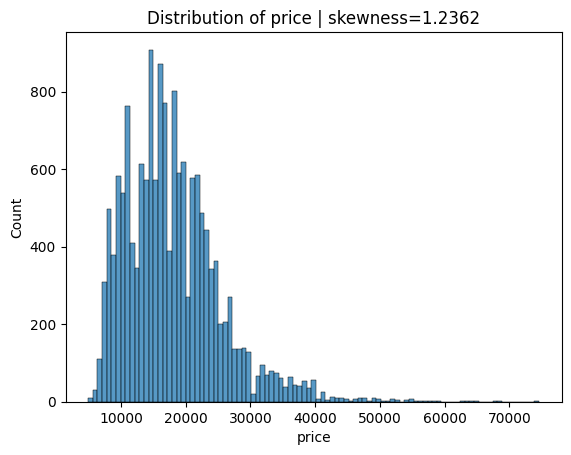

In [462]:
# Plot histograms for target feature
price_skewness = round(df[TARGET].skew()[0], 4)

sns.histplot(data=df, x=TARGET[0])
plt.title(f'Distribution of {TARGET[0]} | skewness={price_skewness}')
plt.show()


**The target variable seems to be skewed. Perform suitable transformation on the target.**

In [463]:
df['price_log_transformed'] = np.log(df['price'])
TARGET_LOG_TRANSFORMED = ['price_log_transformed']

/tmp/ipykernel_682/3293341574.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  log_transformed_price_skewness = round(df[TARGET_LOG_TRANSFORMED].skew()[0], 4)


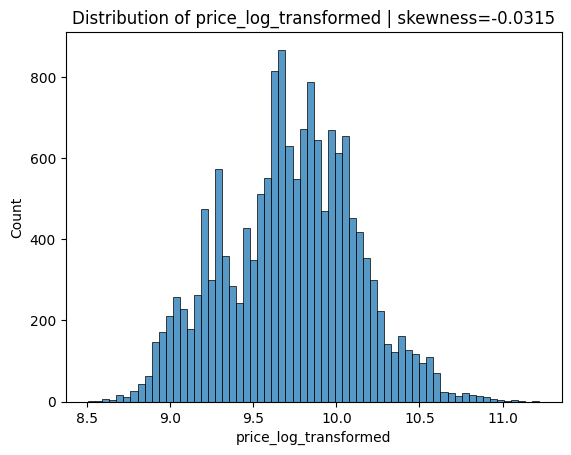

In [464]:
# Transform the target feature
log_transformed_price_skewness = round(df[TARGET_LOG_TRANSFORMED].skew()[0], 4)

sns.histplot(data=df, x=TARGET_LOG_TRANSFORMED[0])
plt.title(f'Distribution of {TARGET_LOG_TRANSFORMED[0]} | skewness={log_transformed_price_skewness}')
plt.show()


### **2.2 Correlation analysis** <font color = red> [6 marks] </font>

#### **2.2.1** <font color =red> [3 marks] </font>
Plot the correlation map between features and target variable.

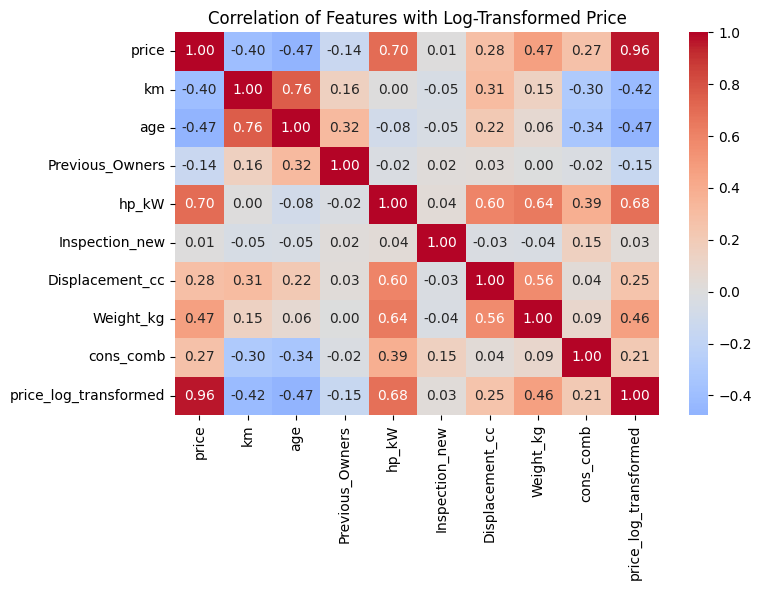

In [465]:
# Visualise correlation
corr = df.corr(numeric_only=True)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title('Correlation of Features with Log-Transformed Price')
plt.tight_layout()
plt.show()

#### **2.2.2** <font color =red> [3 marks] </font>
Analyse correlation between categorical features and target variable.

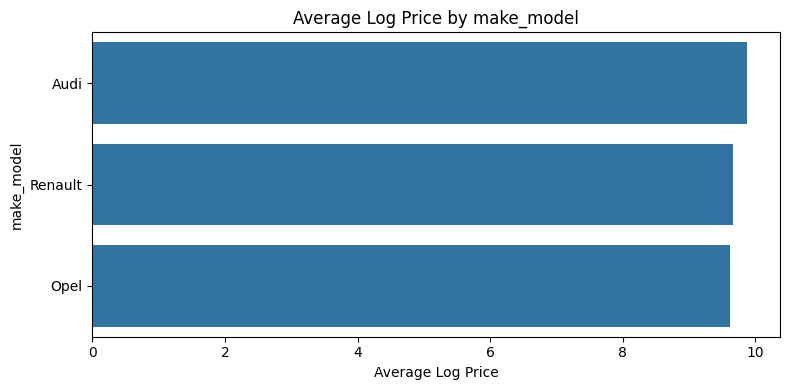

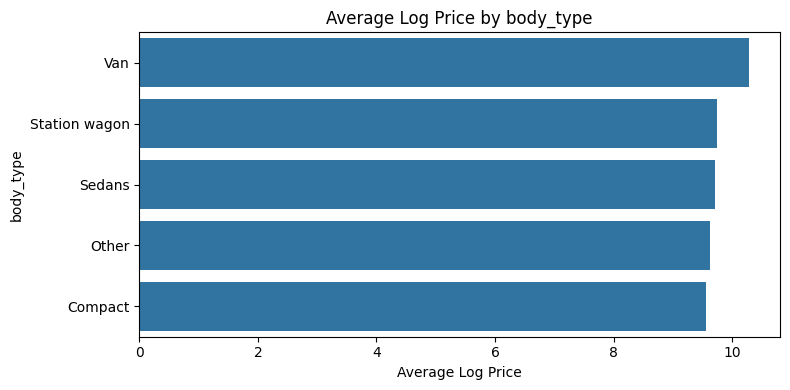

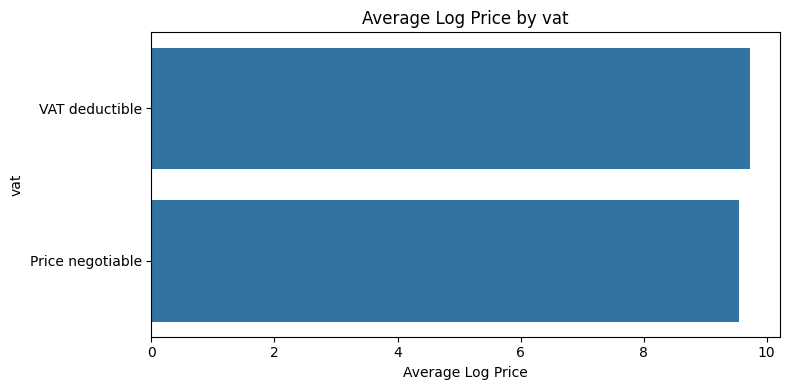

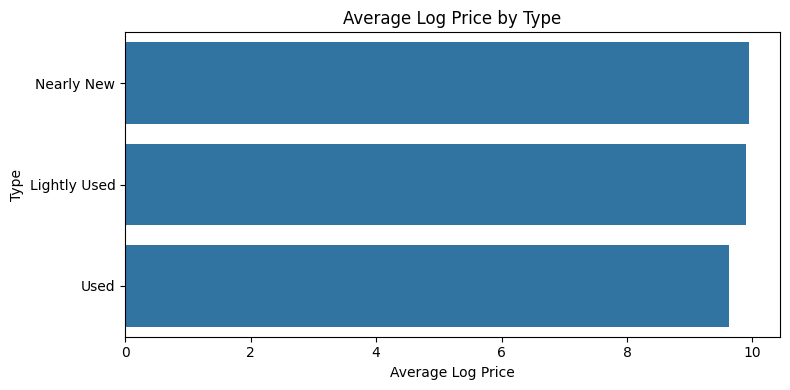

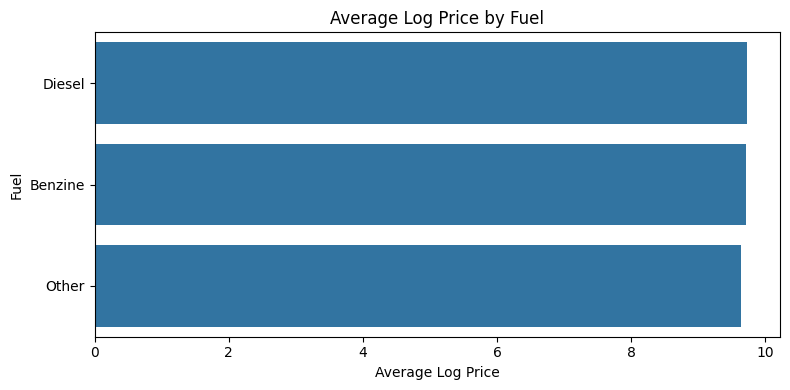

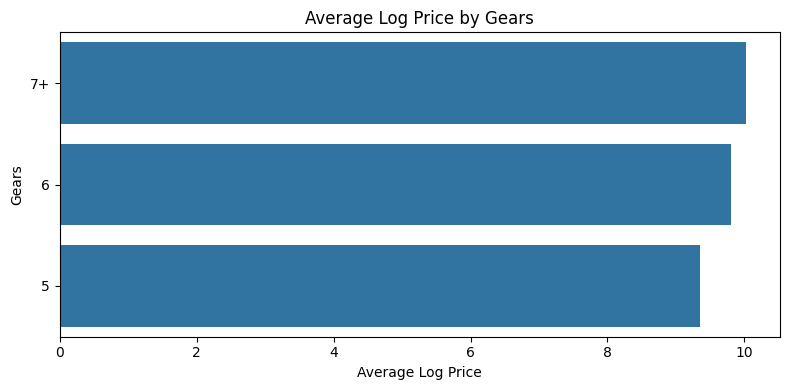

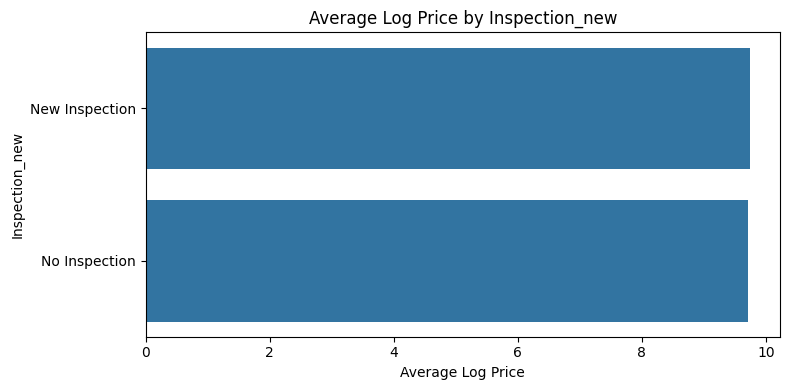

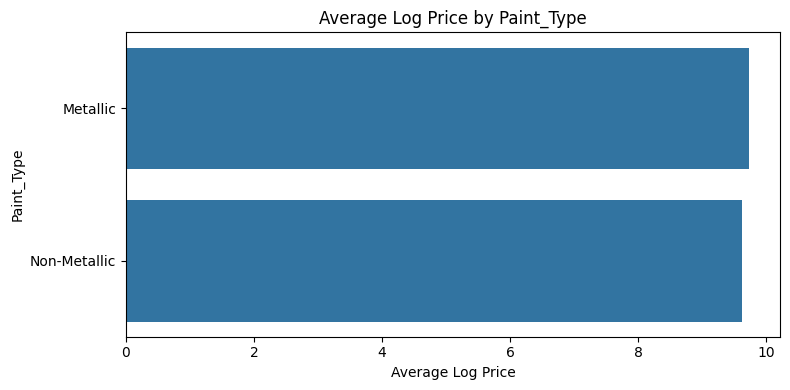

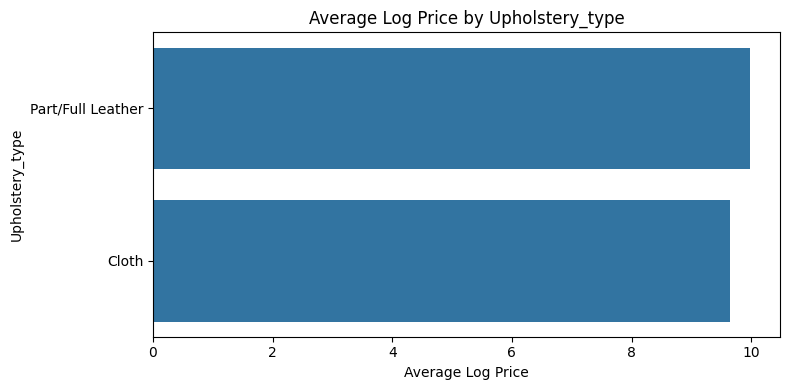

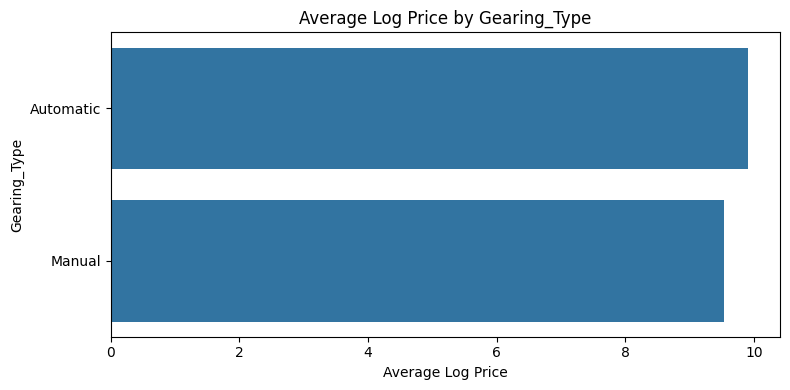

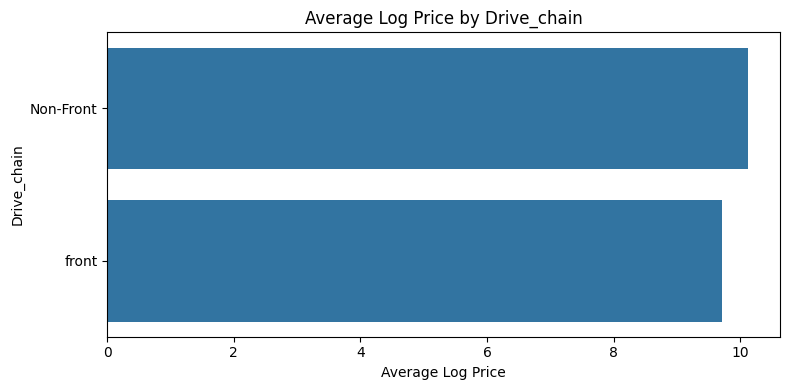

In [466]:
# Comparing average values of target for different categories
for col in CAT_FEATURES_LOW_CARDINALITY:

    avg_price = (
        df.groupby(col, as_index=False)['price_log_transformed']
          .mean()
          .sort_values('price_log_transformed', ascending=False)
    )

    if col == 'Inspection_new':
        avg_price[col] = avg_price[col].map({
            0: 'No Inspection',
            1: 'New Inspection'
        })

    plt.figure(figsize=(8,4))

    sns.barplot(
        data=avg_price,
        x='price_log_transformed',
        y=col
    )

    plt.title(f'Average Log Price by {col}')
    plt.xlabel('Average Log Price')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

### **2.3 Outlier analysis** <font color = red> [5 marks] </font>

#### **2.3.1** <font color =red> [2 marks] </font>
Identify potential outliers in the data.

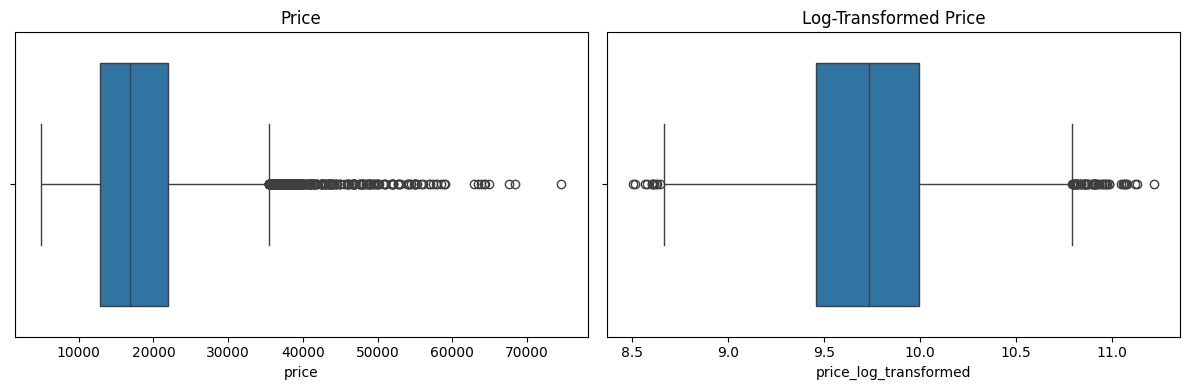

In [467]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=df['price'], ax=axes[0])
axes[0].set_title('Price')

sns.boxplot(x=df['price_log_transformed'], ax=axes[1])
axes[1].set_title('Log-Transformed Price')

plt.tight_layout()
plt.show()

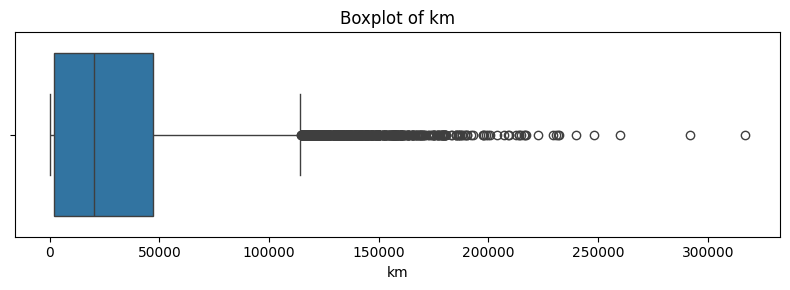

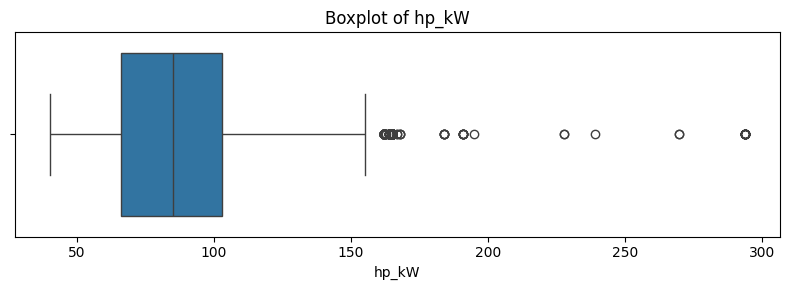

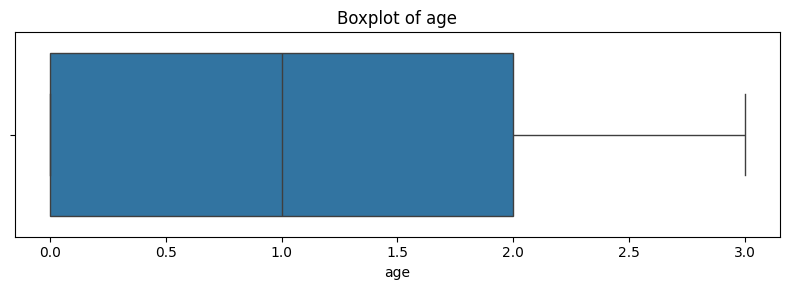

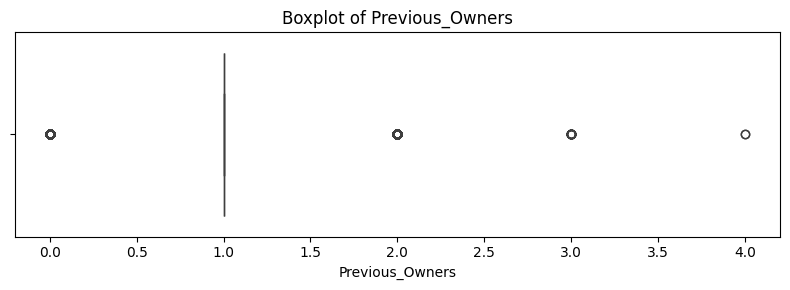

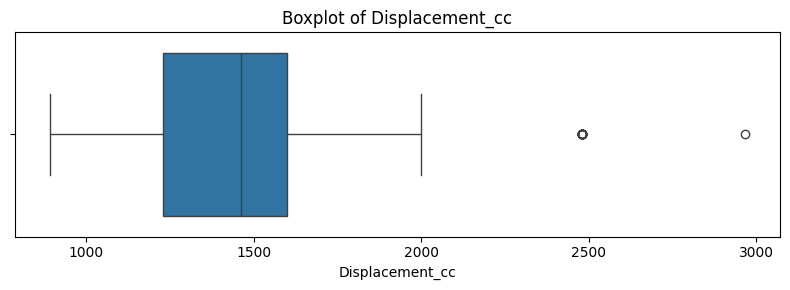

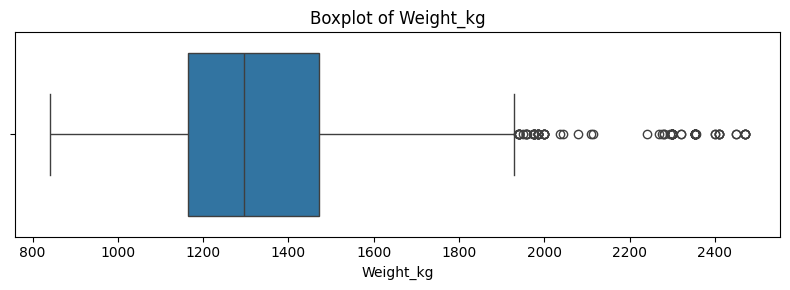

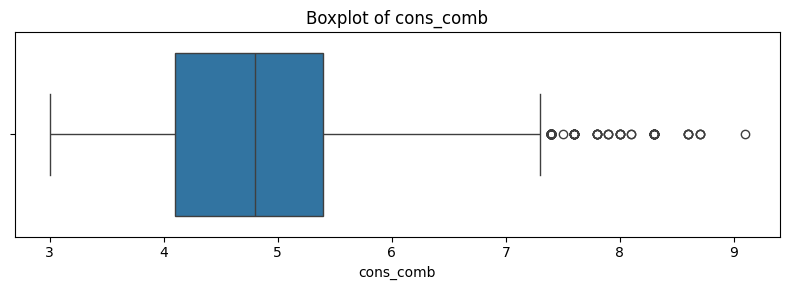

In [468]:
# Outliers present in each column
for col in NUM_FEATURES:
    plt.figure(figsize=(8, 3))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()


#### **2.3.2** <font color =red> [3 marks] </font>
Handle the outliers suitably.

In [469]:
# checking skewness
for col in NUM_FEATURES:
    print(f"skew for the feature - {col}: {df[col].skew():.3f}")

skew for the feature - km: 1.623
skew for the feature - hp_kW: 1.293
skew for the feature - age: 0.176
skew for the feature - Previous_Owners: 1.075
skew for the feature - Displacement_cc: -0.097
skew for the feature - Weight_kg: 1.082
skew for the feature - cons_comb: 0.419


In [470]:
df['km_log_transformed'] = np.log1p(df['km'])
df['km_sqrt_transformed'] = np.sqrt(df['km'])
df['hp_kW_log_transformed'] = np.log(df['hp_kW'])
df['Weight_kg_log_transformed'] = np.log(df['Weight_kg'])

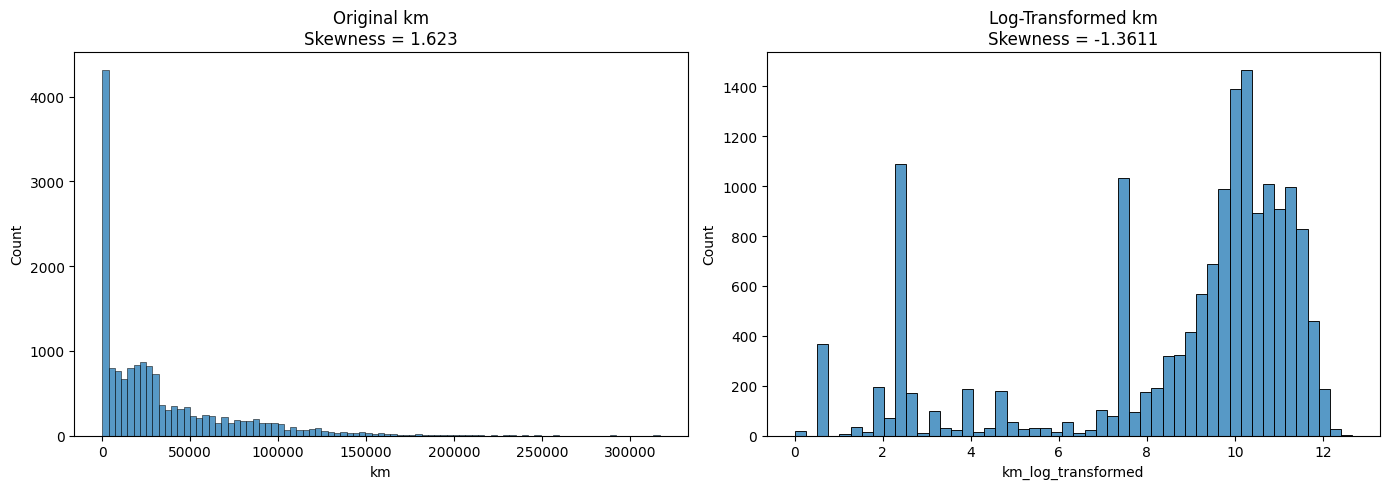

In [471]:
km_skew = round(df['km'].skew(), 4)
log_km_skew = round(df['km_log_transformed'].skew(), 4)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original km distribution
sns.histplot(data=df, x='km', ax=axes[0])
axes[0].set_title(f'Original km\nSkewness = {km_skew}')
axes[0].set_xlabel('km')

# Log-transformed km distribution
sns.histplot(data=df, x='km_log_transformed', ax=axes[1])
axes[1].set_title(f'Log-Transformed km\nSkewness = {log_km_skew}')
axes[1].set_xlabel('km_log_transformed')

plt.tight_layout()
plt.show()

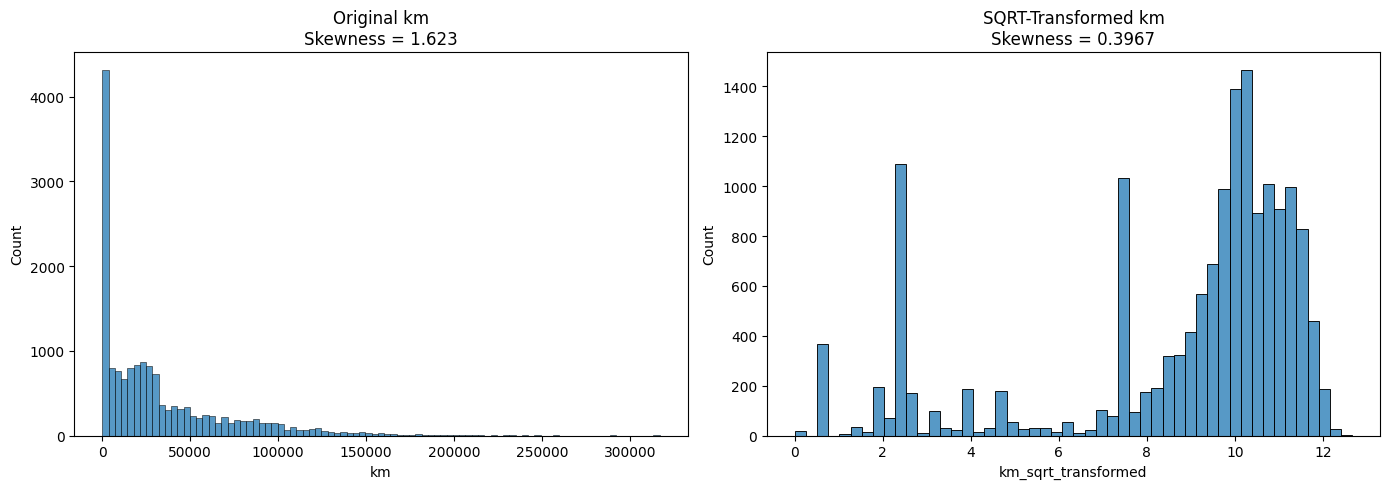

In [472]:
km_skew = round(df['km'].skew(), 4)
sqrt_km_skew = round(df['km_sqrt_transformed'].skew(), 4)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original km distribution
sns.histplot(data=df, x='km', ax=axes[0])
axes[0].set_title(f'Original km\nSkewness = {km_skew}')
axes[0].set_xlabel('km')

# Log-transformed km distribution
sns.histplot(data=df, x='km_log_transformed', ax=axes[1])
axes[1].set_title(f'SQRT-Transformed km\nSkewness = {sqrt_km_skew}')
axes[1].set_xlabel('km_sqrt_transformed')

plt.tight_layout()
plt.show()

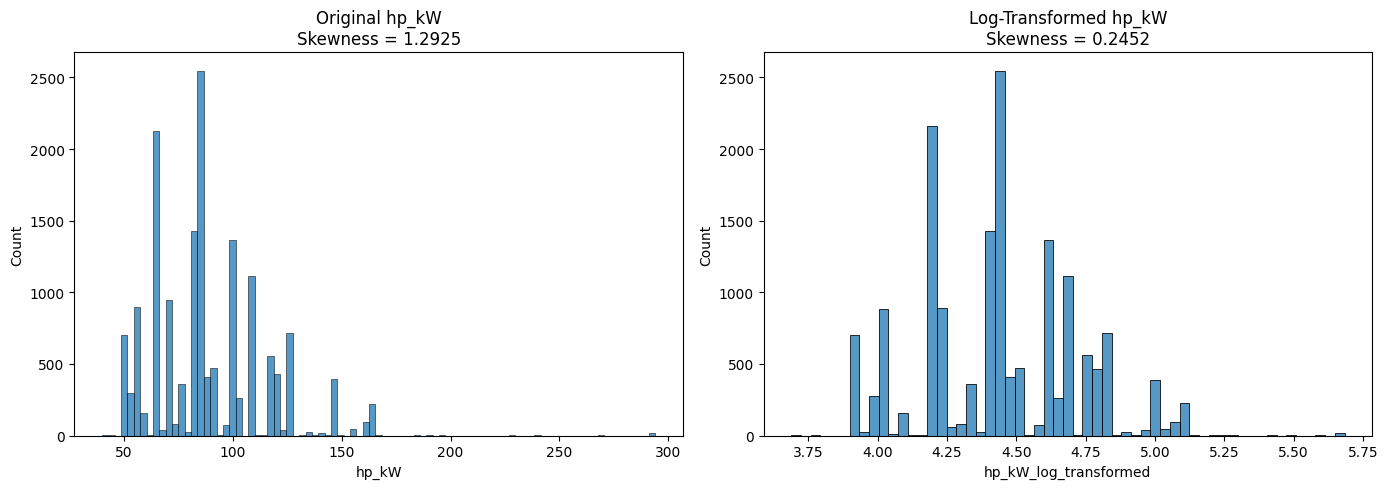

In [473]:
hp_kw_skew = round(df['hp_kW'].skew(), 4)
log_hp_kw_skew = round(df['hp_kW_log_transformed'].skew(), 4)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original hp_kW distribution
sns.histplot(data=df, x='hp_kW', ax=axes[0])
axes[0].set_title(f'Original hp_kW\nSkewness = {hp_kw_skew}')
axes[0].set_xlabel('hp_kW')

# Log-transformed hp_kW distribution
sns.histplot(data=df, x='hp_kW_log_transformed', ax=axes[1])
axes[1].set_title(f'Log-Transformed hp_kW\nSkewness = {log_hp_kw_skew}')
axes[1].set_xlabel('hp_kW_log_transformed')

plt.tight_layout()
plt.show()

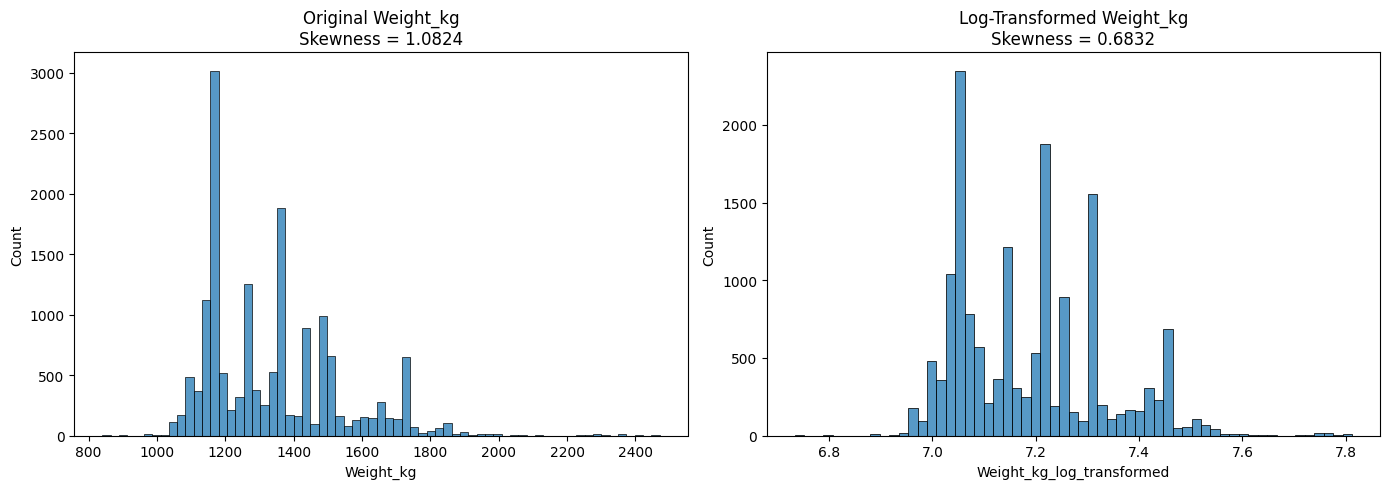

In [474]:
weight_skew = round(df['Weight_kg'].skew(), 4)
log_weight_skew = round(df['Weight_kg_log_transformed'].skew(), 4)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original Weight_kg distribution
sns.histplot(data=df, x='Weight_kg', ax=axes[0])
axes[0].set_title(f'Original Weight_kg\nSkewness = {weight_skew}')
axes[0].set_xlabel('Weight_kg')

# Log-transformed Weight_kg distribution
sns.histplot(data=df, x='Weight_kg_log_transformed', ax=axes[1])
axes[1].set_title(f'Log-Transformed Weight_kg\nSkewness = {log_weight_skew}')
axes[1].set_xlabel('Weight_kg_log_transformed')

plt.tight_layout()
plt.show()

### **2.4 Feature Engineering** <font color = red> [11 marks] </font>

#### **2.4.1**
Fix any redundant columns and create new ones if needed.

In [475]:
NUM_FEATURES_FINAL = [
    'km_sqrt_transformed',
    'hp_kW_log_transformed',
    'age',
    'Previous_Owners',
    'Displacement_cc',
    'Weight_kg_log_transformed',
    'cons_comb'
]

In [476]:
CAT_FEATURES_FINAL = CAT_FEATURES_LOW_CARDINALITY.copy()

In [477]:
CAT_FEATURES_FINAL

['make_model',
 'body_type',
 'vat',
 'Type',
 'Fuel',
 'Gears',
 'Inspection_new',
 'Paint_Type',
 'Upholstery_type',
 'Gearing_Type',
 'Drive_chain']

In [478]:
TARGET_LOG_TRANSFORMED

['price_log_transformed']

#### **2.4.2** <font color =red> [4 marks] </font>
Analysis and feature engineering on `['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']`.

These columns contains lists of features present. Decide on how to include these features in the predictors.

In [479]:
def create_multilabel_features(
    df,
    column,
    separator=",",
    min_support=0.05,
    max_support=0.95,
    top_n=20,
    create_count_feature=True,
    drop_original=False
):
    """
    Create feature count and binary indicator features from a multi-label column.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.

    column : str
        Name of the multi-label column.

    separator : str, default=","
        Delimiter separating values within a cell.

    min_support : float, default=0.05
        Minimum fraction of rows in which a feature must appear
        to be retained.

    max_support : float, default=0.95
        Maximum fraction of rows in which a feature may appear.
        Features appearing in more than this fraction of rows
        will be excluded.

    top_n : int, default=20
        Maximum number of binary features to create.
        If more than top_n features satisfy the support criteria,
        only the top_n most frequent features are retained.

    create_count_feature : bool, default=True
        Whether to create <column>_count feature.

    drop_original : bool, default=False
        Whether to drop the original text column.

    Returns
    -------
    pd.DataFrame
        DataFrame with newly created features.

    list
        List of selected feature names.
    """

    df = df.copy()

    # Split values
    split_values = (
        df[column]
        .fillna("")
        .astype(str)
        .apply(
            lambda x: [
                item.strip()
                for item in x.split(separator)
                if item.strip()
            ]
        )
    )

    n_rows = len(df)

    # Create count feature
    if create_count_feature:
        df[f"{column}_count"] = split_values.apply(len)

    # Calculate document frequency
    counter = Counter()

    for items in split_values:
        counter.update(set(items))

    freq_df = pd.DataFrame(
        {
            "feature": counter.keys(),
            "count": counter.values()
        }
    )

    freq_df["support"] = freq_df["count"] / n_rows

    # Apply support filtering
    freq_df = freq_df[
        (freq_df["support"] >= min_support) &
        (freq_df["support"] <= max_support)
    ]

    # Sort by frequency
    freq_df = freq_df.sort_values(
        "count",
        ascending=False
    )

    # Restrict to top N
    freq_df = freq_df.head(top_n)

    selected_features = freq_df["feature"].tolist()

    # Create binary indicators
    for feature in selected_features:

        clean_feature = re.sub(
            r"[^A-Za-z0-9]+",
            "_",
            feature.strip()
        ).strip("_")

        new_col = f"{column}_{clean_feature}"

        df[new_col] = split_values.apply(
            lambda x: int(feature in x)
        )

    if drop_original:
        df.drop(columns=[column], inplace=True)

    return df, selected_features

In [480]:
# Check unique values in each feature spec column
df, comfort_features = create_multilabel_features(
    df,
    column="Comfort_Convenience",
    min_support=0.05,
    max_support=0.95,
    top_n=20
)

df, media_features = create_multilabel_features(
    df,
    column="Entertainment_Media",
    min_support=0.05,
    max_support=0.95,
    top_n=20
)

df, extras_features = create_multilabel_features(
    df,
    column="Extras",
    min_support=0.05,
    max_support=0.95,
    top_n=20
)

df, safety_features = create_multilabel_features(
    df,
    column="Safety_Security",
    min_support=0.05,
    max_support=0.95,
    top_n=20
)

Out of these features, we will check the ones which are present in most of the cars or are absent from most of the cars. These kinds of features can be removed as they just increase the dimensionality without explaining the variance.

In [481]:
NEW_NUM_FEATURE_ENGG = [itm for itm in df.columns if itm.endswith('_count')]
NEW_CAT_FEATURE_ENGG = [
    col for col in df.columns
    if col.startswith((
        'Comfort_Convenience_',
        'Entertainment_Media_',
        'Extras_',
        'Safety_Security_'
    ))
    and not col.endswith('_count')
]

In [482]:
len(NEW_NUM_FEATURE_ENGG), len(NEW_CAT_FEATURE_ENGG)

(4, 57)

#### **2.4.3** <font color =red> [3 marks] </font>
Perform feature encoding.

In [483]:
###
# WILL BE DONE AFTER TRAIN TEST SPLIT
###

In [484]:
FEATURES_FINAL = (
    NUM_FEATURES_FINAL +
    CAT_FEATURES_FINAL +
    NEW_NUM_FEATURE_ENGG +
    NEW_CAT_FEATURE_ENGG
)

X = df[FEATURES_FINAL]
y = df['price_log_transformed']

#### **2.4.4** <font color =red> [2 marks] </font>
Split the data into training and testing sets.

In [485]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [486]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (12732, 79)
X_test : (3183, 79)
y_train: (12732,)
y_test : (3183,)


#### **2.4.5** <font color =red> [2 marks] </font>
Scale the features.

In [487]:
NUMERIC_FEATURES_TO_SCALE = (
    NUM_FEATURES_FINAL +
    NEW_NUM_FEATURE_ENGG
)

# Binary engineered features
BINARY_FEATURES = NEW_CAT_FEATURE_ENGG

In [488]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            NUMERIC_FEATURES_TO_SCALE
        ),
        (
            'cat',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore',
                sparse_output=False
            ),
            CAT_FEATURES_FINAL
        )
    ],
    remainder='passthrough'
)

In [489]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [490]:
feature_names = preprocessor.get_feature_names_out()

X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

## **3 Linear Regression Models** <font color =red> [35 marks] </font>


### **3.1 Baseline Linear Regression Model** <font color =red> [10 marks] </font>

#### **3.1.1** <font color =red> [5 marks] </font>
Build and fit a basic linear regression model. Perform evaluation using suitable metrics.

In [491]:
# Initialise and train model
lr = LinearRegression()

# Fit model
lr.fit(X_train_processed, y_train)

LinearRegression()

In [492]:
# Training predictions
y_train_pred = lr.predict(X_train_processed)

# Testing predictions
y_test_pred = lr.predict(X_test_processed)

In [493]:
# Evaluate the model's performance
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
lr_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Testing metrics
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
lr_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

In [494]:
print("Training Performance")
print(f"R²   : {train_r2:.4f}")
print(f"MAE  : {train_mae:.4f}")
print(f"RMSE : {lr_train_rmse:.4f}")

print("\nTesting Performance")
print(f"R²   : {test_r2:.4f}")
print(f"MAE  : {test_mae:.4f}")
print(f"RMSE : {lr_test_rmse:.4f}")

Training Performance
R²   : 0.9109
MAE  : 0.0887
RMSE : 0.1187

Testing Performance
R²   : 0.9172
MAE  : 0.0868
RMSE : 0.1150


In [495]:
results = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'R2': [train_r2, test_r2],
    'MAE': [train_mae, test_mae],
    'RMSE': [lr_train_rmse, lr_test_rmse]
})

results

,Dataset,R2,MAE,RMSE
0,Train,0.910949,0.088676,0.118713
1,Test,0.917214,0.086776,0.115040


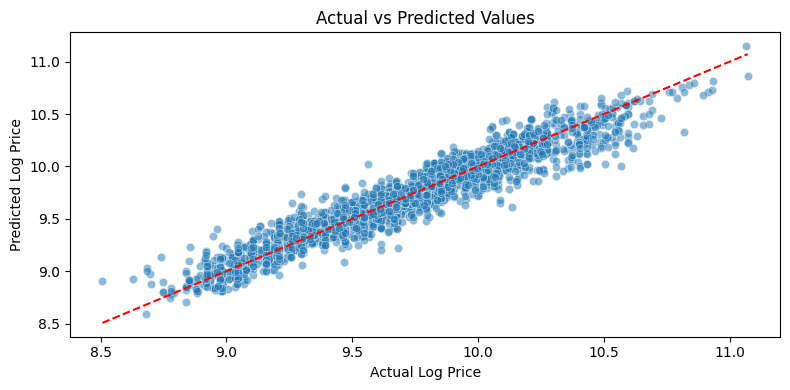

In [496]:
plt.figure(figsize=(8,4))

sns.scatterplot(
    x=y_test,
    y=y_test_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Actual vs Predicted Values")

plt.tight_layout()
plt.show()

#### **3.1.2** <font color =red> [5 marks] </font>
Analyse residuals and check other assumptions of linear regression.

Check for linearity by analysing residuals vs predicted values

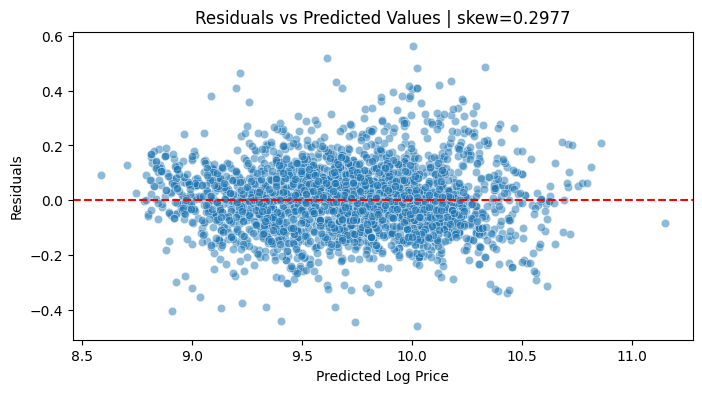

In [497]:
# Linearity check: Plot residuals vs fitted values
residuals = y_test - y_test_pred
residual_skew = round(residuals.skew(),4)

plt.figure(figsize=(8,4))

sns.scatterplot(
    x=y_test_pred,
    y=residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Log Price")
plt.ylabel("Residuals")
plt.title(f"Residuals vs Predicted Values | skew={residual_skew}")

plt.show()

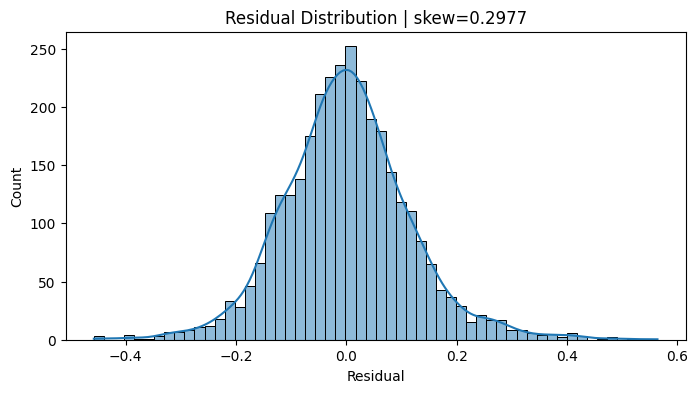

In [498]:
plt.figure(figsize=(8,4))

sns.histplot(
    residuals,
    kde=True
)

plt.title(f"Residual Distribution | skew={residual_skew}")
plt.xlabel("Residual")

plt.show()

Check normality in residual distribution

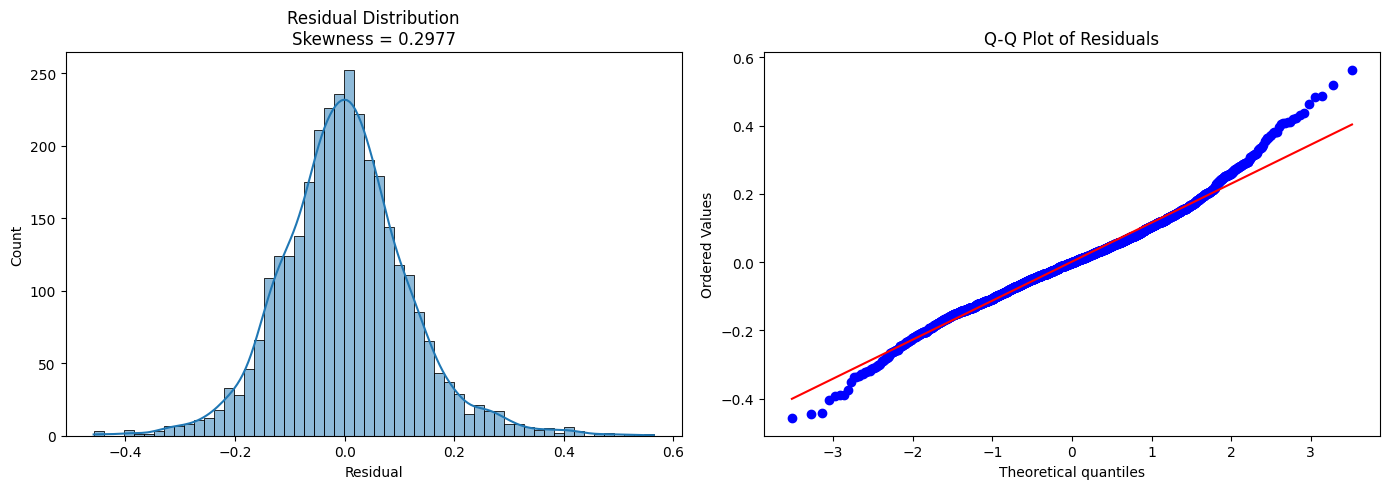

In [499]:
# Check the normality of residuals by plotting their distribution

residuals = y_test - y_test_pred
residual_skew = round(residuals.skew(), 4)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(
    residuals,
    kde=True,
    ax=axes[0]
)
axes[0].set_title(
    f"Residual Distribution\nSkewness = {residual_skew}"
)
axes[0].set_xlabel("Residual")

# Q-Q Plot
stats.probplot(
    residuals,
    dist="norm",
    plot=axes[1]
)
axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

Check multicollinearity using Variance Inflation Factor (VIF) and handle features with high VIF.

In [500]:
def calculate_vif(df):
    vif_df = pd.DataFrame({
        "Feature": df.columns,
        "VIF": [
            variance_inflation_factor(df.values, i)
            for i in range(df.shape[1])
        ]
    })

    return vif_df.sort_values("VIF", ascending=False)

In [501]:
# Check for multicollinearity and handle
vif_df = calculate_vif(X_train_processed)
vif_df.head(20)

,Feature,VIF
8,num__Entertainment_Media_count,101.540015
28,cat__Drive_chain_front,90.469576
7,num__Comfort_Convenience_count,42.625169
10,num__Safety_Security_count,31.011371
67,remainder__Safety_Security_Driver_side_airbag,30.923287
66,remainder__Safety_Security_ABS,28.895388
49,remainder__Entertainment_Media_On_board_computer,28.671475
51,remainder__Entertainment_Media_Bluetooth,28.657239
29,remainder__Comfort_Convenience_Air_conditioning,27.836124
50,remainder__Entertainment_Media_Radio,25.859539


In [502]:
high_vif_cols = [
  'num__Comfort_Convenience_count',
  'num__Entertainment_Media_count',
  'num__Extras_count',
  'num__Safety_Security_count',
  'cat__Drive_chain_front'
]

X_train_processed = X_train_processed.drop(
  columns=high_vif_cols
)

X_test_processed = X_test_processed.drop(
  columns=high_vif_cols
)

vif_df = calculate_vif(X_train_processed)

vif_df.head(20)

,Feature,VIF
62,remainder__Safety_Security_Driver_side_airbag,27.620654
61,remainder__Safety_Security_ABS,26.089832
24,remainder__Comfort_Convenience_Air_conditioning,23.488127
25,remainder__Comfort_Convenience_Power_windows,23.343294
64,remainder__Safety_Security_Passenger_side_airbag,22.042215
13,cat__vat_VAT deductible,18.752381
63,remainder__Safety_Security_Power_steering,16.023378
66,remainder__Safety_Security_Side_airbag,14.183289
65,remainder__Safety_Security_Electronic_stabilit...,13.798649
30,remainder__Comfort_Convenience_Parking_assist_...,13.613492


### **3.2 Ridge Regression Implementation** <font color =red> [10 marks] </font>

#### **3.2.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [503]:
# List of alphas to tune for Ridge regularisation
ridge_alphas = np.logspace(-4, 4, 30)

#### **3.2.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [504]:
# Applying Ridge regression
ridge = Ridge()

# Grid Search
ridge_grid = GridSearchCV(
    estimator=ridge,
    param_grid={'alpha': ridge_alphas},
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

ridge_grid.fit(X_train_processed, y_train)

GridSearchCV(cv=5, estimator=Ridge(), n_jobs=-1,
             param_grid={'alpha': array([1.00000000e-04, 1.88739182e-04, 3.56224789e-04, 6.72335754e-04,
       1.26896100e-03, 2.39502662e-03, 4.52035366e-03, 8.53167852e-03,
       1.61026203e-02, 3.03919538e-02, 5.73615251e-02, 1.08263673e-01,
       2.04335972e-01, 3.85662042e-01, 7.27895384e-01, 1.37382380e+00,
       2.59294380e+00, 4.89390092e+00, 9.23670857e+00, 1.74332882e+01,
       3.29034456e+01, 6.21016942e+01, 1.17210230e+02, 2.21221629e+02,
       4.17531894e+02, 7.88046282e+02, 1.48735211e+03, 2.80721620e+03,
       5.29831691e+03, 1.00000000e+04])},
             scoring='neg_root_mean_squared_error')

In [505]:
# Best alpha
best_alpha = ridge_grid.best_params_['alpha']
best_score = -ridge_grid.best_score_

print(f"Best Alpha: {best_alpha}")
print(f"Best CV RMSE: {best_score:.4f}")

Best Alpha: 2.592943797404667
Best CV RMSE: 0.1208


In [506]:
# Plot train and test scores against alpha
train_scores = []
test_scores = []

for alpha in ridge_alphas:

    ridge = Ridge(alpha=alpha)

    ridge.fit(X_train_processed, y_train)

    # Predictions
    y_train_pred = ridge.predict(X_train_processed)
    y_test_pred = ridge.predict(X_test_processed)

    # R² scores
    train_scores.append(
        r2_score(y_train, y_train_pred)
    )

    test_scores.append(
        r2_score(y_test, y_test_pred)
    )

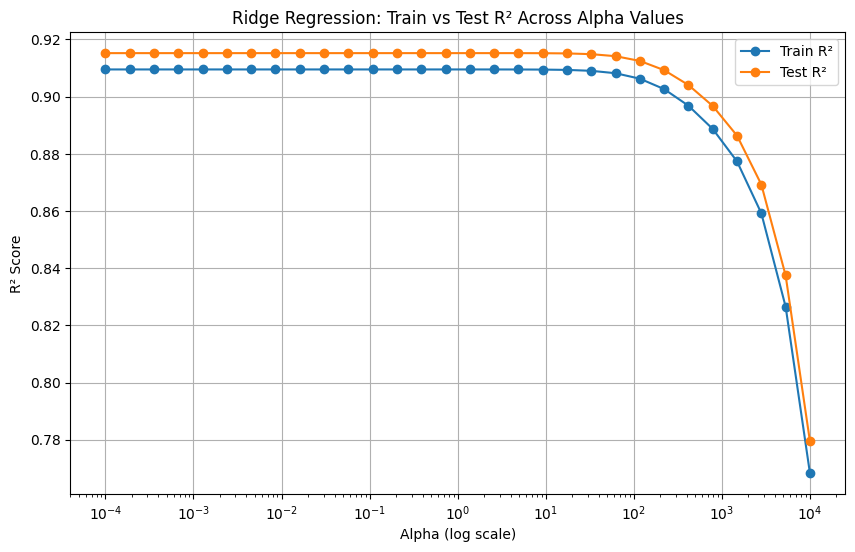

In [507]:
# Plot
plt.figure(figsize=(10, 6))

plt.plot(
    ridge_alphas,
    train_scores,
    marker='o',
    label='Train R²'
)

plt.plot(
    ridge_alphas,
    test_scores,
    marker='o',
    label='Test R²'
)

plt.xscale('log')

plt.xlabel('Alpha (log scale)')
plt.ylabel('R² Score')
plt.title('Ridge Regression: Train vs Test R² Across Alpha Values')

plt.legend()
plt.grid(True)

plt.show()


In [508]:
train_rmse = []
test_rmse = []

for alpha in ridge_alphas:

    ridge = Ridge(alpha=alpha)

    ridge.fit(X_train_processed, y_train)

    y_train_pred = ridge.predict(X_train_processed)
    y_test_pred = ridge.predict(X_test_processed)

    train_rmse.append(
        np.sqrt(mean_squared_error(y_train, y_train_pred))
    )

    test_rmse.append(
        np.sqrt(mean_squared_error(y_test, y_test_pred))
    )

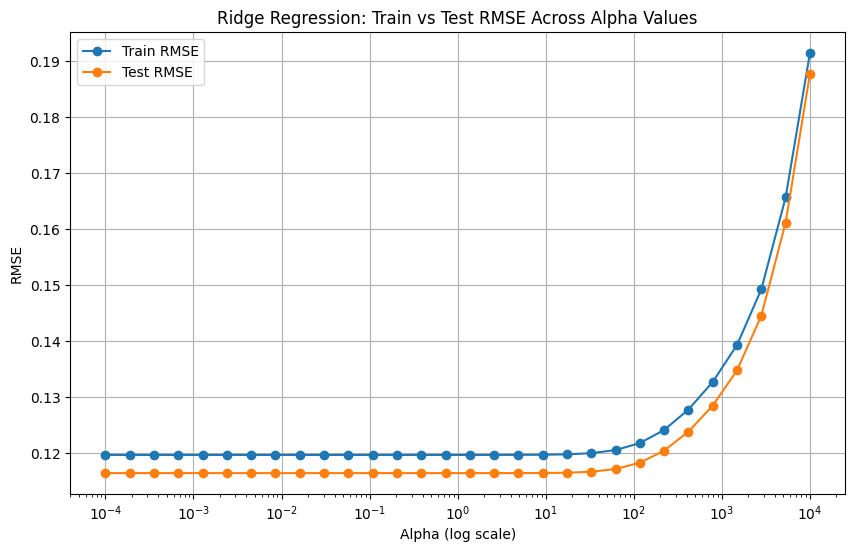

In [509]:
plt.figure(figsize=(10,6))

plt.plot(
    ridge_alphas,
    train_rmse,
    marker='o',
    label='Train RMSE'
)

plt.plot(
    ridge_alphas,
    test_rmse,
    marker='o',
    label='Test RMSE'
)

plt.xscale('log')

plt.xlabel('Alpha (log scale)')
plt.ylabel('RMSE')
plt.title('Ridge Regression: Train vs Test RMSE Across Alpha Values')

plt.legend()
plt.grid(True)

plt.show()

Find the best alpha value.

We will get some best value of alpha above. This however is not the most accurate value but the best value from the given list. Now we have a rough estimate of the range that best alpha falls in. Let us do another iteration over the values in a smaller range.

#### **3.2.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [510]:
# Fine search around previous optimum
fine_alphas = np.linspace(1.5, 3.5, 100)

cv_rmse = []

for alpha in fine_alphas:
    ridge = Ridge(alpha=alpha)

    scores = cross_val_score(
        ridge,
        X_train_processed,
        y_train,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    cv_rmse.append(-scores.mean())

In [511]:
# Best alpha
best_idx = np.argmin(cv_rmse)
best_alpha_fine = fine_alphas[best_idx]
best_rmse_fine = cv_rmse[best_idx]

print(f"Optimal Alpha: {best_alpha_fine:.4f}")
print(f"CV RMSE      : {best_rmse_fine:.6f}")

Optimal Alpha: 1.9848
CV RMSE      : 0.120759


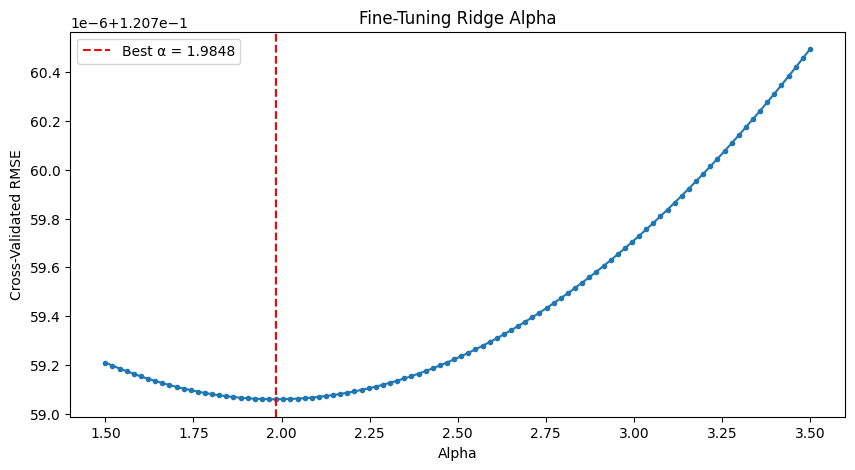

In [512]:
plt.figure(figsize=(10, 5))

plt.plot(
    fine_alphas,
    cv_rmse,
    marker='o',
    markersize=3
)

plt.axvline(
    best_alpha_fine,
    color='red',
    linestyle='--',
    label=f'Best α = {best_alpha_fine:.4f}'
)

plt.xlabel('Alpha')
plt.ylabel('Cross-Validated RMSE')
plt.title('Fine-Tuning Ridge Alpha')
plt.legend()

plt.show()

Plot the error-alpha graph again and find the actual optimal value for alpha.

In [513]:
# Set best alpha for Ridge regression
# Fit the Ridge model to get the coefficients of the fitted model
# Best alpha obtained from tuning
best_alpha = 1.9848

# Fit Ridge model
ridge_final = Ridge(alpha=best_alpha)

ridge_final.fit(
    X_train_processed,
    y_train
)

Ridge(alpha=1.9848)

In [514]:
# Show the coefficients for each feature
ridge_coefficients = pd.DataFrame({
    'Feature': X_train_processed.columns,
    'Coefficient': ridge_final.coef_
})

ridge_coefficients = ridge_coefficients.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

ridge_coefficients

,Feature,Coefficient
8,cat__make_model_Renault,-0.321271
7,cat__make_model_Opel,-0.309799
12,cat__body_type_Van,0.248166
1,num__hp_kW_log_transformed,0.161890
0,num__km_sqrt_transformed,-0.113697
...,...,...
39,remainder__Comfort_Convenience_Hill_Holder,0.001617
76,remainder__Safety_Security_Emergency_brake_ass...,0.001614
46,remainder__Entertainment_Media_Bluetooth,0.001039
21,cat__Paint_Type_Non-Metallic,0.000875


In [515]:
# Evaluate the Ridge model on the test data
# Predictions
y_train_pred_ridge = ridge_final.predict(X_train_processed)
y_test_pred_ridge = ridge_final.predict(X_test_processed)

# Training metrics
ridge_train_r2 = r2_score(y_train, y_train_pred_ridge)
ridge_train_mae = mean_absolute_error(y_train, y_train_pred_ridge)
ridge_train_rmse = np.sqrt(
    mean_squared_error(y_train, y_train_pred_ridge)
)

# Test metrics
ridge_test_r2 = r2_score(y_test, y_test_pred_ridge)
ridge_test_mae = mean_absolute_error(y_test, y_test_pred_ridge)
ridge_test_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_ridge)
)

print("RIDGE REGRESSION PERFORMANCE")
print("-" * 40)

print("Training Performance")
print(f"R²   : {ridge_train_r2:.4f}")
print(f"MAE  : {ridge_train_mae:.4f}")
print(f"RMSE : {ridge_train_rmse:.4f}")

print("\nTesting Performance")
print(f"R²   : {ridge_test_r2:.4f}")
print(f"MAE  : {ridge_test_mae:.4f}")
print(f"RMSE : {ridge_test_rmse:.4f}")


RIDGE REGRESSION PERFORMANCE
----------------------------------------
Training Performance
R²   : 0.9095
MAE  : 0.0894
RMSE : 0.1197

Testing Performance
R²   : 0.9152
MAE  : 0.0881
RMSE : 0.1164


### **3.3 Lasso Regression Implementation** <font color =red> [10 marks] </font>

#### **3.3.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [516]:
# List of alphas to tune for Lasso regularisation
lasso_alphas = np.logspace(-5, 1, 50)

#### **3.3.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [517]:
# Initialise Lasso regression model
lasso_grid = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid={'alpha': lasso_alphas},
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

lasso_grid.fit(
    X_train_processed,
    y_train
)

GridSearchCV(cv=5, estimator=Lasso(max_iter=10000), n_jobs=-1,
             param_grid={'alpha': array([1.00000000e-05, 1.32571137e-05, 1.75751062e-05, 2.32995181e-05,
       3.08884360e-05, 4.09491506e-05, 5.42867544e-05, 7.19685673e-05,
       9.54095476e-05, 1.26485522e-04, 1.67683294e-04, 2.22299648e-04,
       2.94705170e-04, 3.90693994e-04, 5.17947468e-04, 6.86648845e-04,
       9.10298178e-04, 1.206792...
       2.68269580e-02, 3.55648031e-02, 4.71486636e-02, 6.25055193e-02,
       8.28642773e-02, 1.09854114e-01, 1.45634848e-01, 1.93069773e-01,
       2.55954792e-01, 3.39322177e-01, 4.49843267e-01, 5.96362332e-01,
       7.90604321e-01, 1.04811313e+00, 1.38949549e+00, 1.84206997e+00,
       2.44205309e+00, 3.23745754e+00, 4.29193426e+00, 5.68986603e+00,
       7.54312006e+00, 1.00000000e+01])},
             scoring='neg_root_mean_squared_error')

In [518]:
best_alpha_lasso = lasso_grid.best_params_['alpha']
best_rmse_lasso = -lasso_grid.best_score_

print(f"Best Alpha: {best_alpha_lasso:.6f}")
print(f"Best CV RMSE: {best_rmse_lasso:.6f}")

Best Alpha: 0.000018
Best CV RMSE: 0.120759


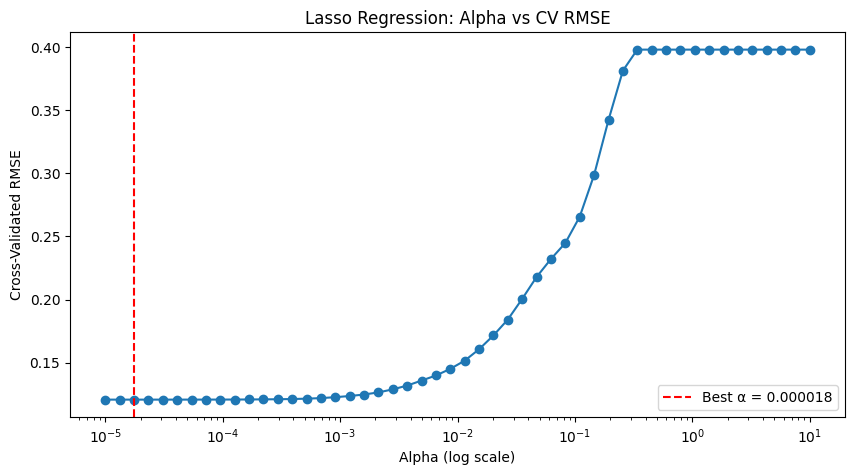

In [519]:
# Plot train and test scores against alpha
cv_rmse = -lasso_grid.cv_results_['mean_test_score']

plt.figure(figsize=(10,5))

plt.plot(
    lasso_alphas,
    cv_rmse,
    marker='o'
)

plt.xscale('log')

plt.axvline(
    best_alpha_lasso,
    color='red',
    linestyle='--',
    label=f'Best α = {best_alpha_lasso:.6f}'
)

plt.xlabel('Alpha (log scale)')
plt.ylabel('Cross-Validated RMSE')
plt.title('Lasso Regression: Alpha vs CV RMSE')

plt.legend()
plt.show()


#### **3.3.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [520]:
# List of alphas to tune for Lasso regularization
fine_alphas = np.logspace(
    np.log10(5e-6),
    np.log10(5e-5),
    100
)


In [521]:
# Tuning Lasso hyperparameters
# Initialise Lasso regression model
lasso_grid = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid={'alpha': fine_alphas},
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

lasso_grid.fit(
    X_train_processed,
    y_train
)

GridSearchCV(cv=5, estimator=Lasso(max_iter=10000), n_jobs=-1,
             param_grid={'alpha': array([5.00000000e-06, 5.11765511e-06, 5.23807876e-06, 5.36133611e-06,
       5.48749383e-06, 5.61662016e-06, 5.74878498e-06, 5.88405976e-06,
       6.02251770e-06, 6.16423370e-06, 6.30928442e-06, 6.45774833e-06,
       6.60970574e-06, 6.76523887e-06, 6.92443186e-06, 7.08737081e-06,
       7.25414389e-06, 7.424841...
       2.92851041e-05, 2.99742125e-05, 3.06795364e-05, 3.14014572e-05,
       3.21403656e-05, 3.28966612e-05, 3.36707533e-05, 3.44630605e-05,
       3.52740116e-05, 3.61040451e-05, 3.69536102e-05, 3.78231664e-05,
       3.87131841e-05, 3.96241449e-05, 4.05565415e-05, 4.15108784e-05,
       4.24876718e-05, 4.34874501e-05, 4.45107543e-05, 4.55581378e-05,
       4.66301673e-05, 4.77274228e-05, 4.88504979e-05, 5.00000000e-05])},
             scoring='neg_root_mean_squared_error')

In [522]:
best_alpha_lasso = lasso_grid.best_params_['alpha']
best_rmse_lasso = -lasso_grid.best_score_

print(f"Best Alpha: {best_alpha_lasso:.6f}")
print(f"Best CV RMSE: {best_rmse_lasso:.6f}")

Best Alpha: 0.000019
Best CV RMSE: 0.120759


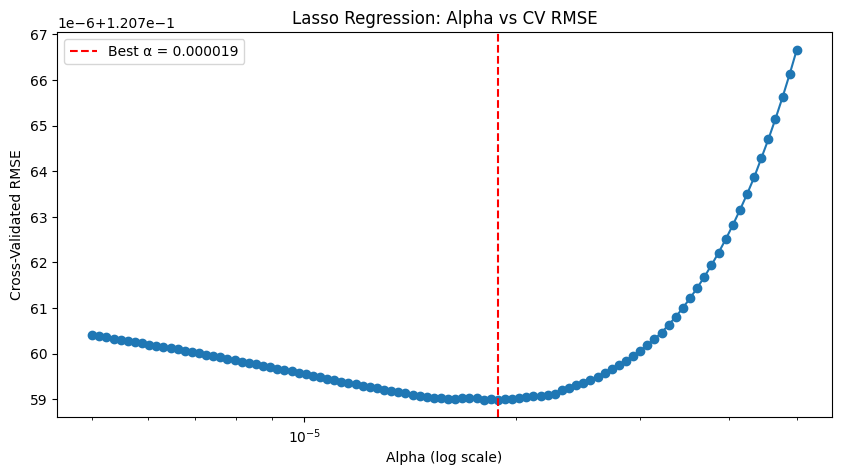

In [523]:
# Plot train and test scores against alpha
cv_rmse = -lasso_grid.cv_results_['mean_test_score']

plt.figure(figsize=(10,5))

plt.plot(
    fine_alphas,
    cv_rmse,
    marker='o'
)

plt.xscale('log')

plt.axvline(
    best_alpha_lasso,
    color='red',
    linestyle='--',
    label=f'Best α = {best_alpha_lasso:.6f}'
)

plt.xlabel('Alpha (log scale)')
plt.ylabel('Cross-Validated RMSE')
plt.title('Lasso Regression: Alpha vs CV RMSE')

plt.legend()
plt.show()


In [524]:
# Best alpha obtained from tuning
best_alpha_lasso = 0.000019

# Fit Lasso model
lasso_final = Lasso(
    alpha=best_alpha_lasso,
    max_iter=10000,
    random_state=42
)

lasso_final.fit(
    X_train_processed,
    y_train
)

Lasso(alpha=1.9e-05, max_iter=10000, random_state=42)

In [525]:
# Check the coefficients for each feature
lasso_coefficients = pd.DataFrame({
    'Feature': X_train_processed.columns,
    'Coefficient': lasso_final.coef_
})

lasso_coefficients = lasso_coefficients.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

lasso_coefficients


,Feature,Coefficient
8,cat__make_model_Renault,-0.322639
7,cat__make_model_Opel,-0.310663
12,cat__body_type_Van,0.249203
1,num__hp_kW_log_transformed,0.161972
0,num__km_sqrt_transformed,-0.113684
...,...,...
39,remainder__Comfort_Convenience_Hill_Holder,0.001606
76,remainder__Safety_Security_Emergency_brake_ass...,0.001488
46,remainder__Entertainment_Media_Bluetooth,0.000643
21,cat__Paint_Type_Non-Metallic,0.000474


In [526]:
# Evaluate the Lasso model on the test data
# Predictions
y_train_pred_lasso = lasso_final.predict(X_train_processed)
y_test_pred_lasso = lasso_final.predict(X_test_processed)

# Training metrics
lasso_train_r2 = r2_score(y_train, y_train_pred_lasso)
lasso_train_mae = mean_absolute_error(y_train, y_train_pred_lasso)
lasso_train_rmse = np.sqrt(
    mean_squared_error(y_train, y_train_pred_lasso)
)

# Test metrics
lasso_test_r2 = r2_score(y_test, y_test_pred_lasso)
lasso_test_mae = mean_absolute_error(y_test, y_test_pred_lasso)
lasso_test_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_lasso)
)

print("LASSO REGRESSION PERFORMANCE")
print("-" * 40)

print("Training Performance")
print(f"R²   : {lasso_train_r2:.4f}")
print(f"MAE  : {lasso_train_mae:.4f}")
print(f"RMSE : {lasso_train_rmse:.4f}")

print("\nTesting Performance")
print(f"R²   : {lasso_test_r2:.4f}")
print(f"MAE  : {lasso_test_mae:.4f}")
print(f"RMSE : {lasso_test_rmse:.4f}")


LASSO REGRESSION PERFORMANCE
----------------------------------------
Training Performance
R²   : 0.9095
MAE  : 0.0894
RMSE : 0.1197

Testing Performance
R²   : 0.9152
MAE  : 0.0881
RMSE : 0.1164


### **3.4 Regularisation Comparison & Analysis** <font color =red> [5 marks] </font>

#### **3.4.1** <font color =red> [2 marks] </font>
Compare the evaluation metrics for each model.

In [527]:
comparison_df = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression'
    ],

    'Train R²': [
        train_r2,
        ridge_train_r2,
        lasso_train_r2
    ],

    'Test R²': [
        test_r2,
        ridge_test_r2,
        lasso_test_r2
    ],

    'Train MAE': [
        train_mae,
        ridge_train_mae,
        lasso_train_mae
    ],

    'Test MAE': [
        test_mae,
        ridge_test_mae,
        lasso_test_mae
    ],

    'Train RMSE': [
        lr_train_rmse,
        ridge_train_rmse,
        lasso_train_rmse
    ],

    'Test RMSE': [
        lr_test_rmse,
        ridge_test_rmse,
        lasso_test_rmse
    ]
})

comparison_df = comparison_df.round(4)

comparison_df

,Model,Train R²,Test R²,Train MAE,Test MAE,Train RMSE,Test RMSE
0,Linear Regression,0.9109,0.9172,0.0887,0.0868,0.1187,0.1150
1,Ridge Regression,0.9095,0.9152,0.0894,0.0881,0.1197,0.1164
2,Lasso Regression,0.9095,0.9152,0.0894,0.0881,0.1197,0.1164


#### **3.4.2** <font color =red> [3 marks] </font>
Compare the coefficients for the three models.

Also visualise a few of the largest coefficients and the coefficients of features dropped by Lasso.

In [528]:
# retraining the linear regression model on the same feature space for side-by-side comparison
lr_final = LinearRegression()

lr_final.fit(
    X_train_processed,
    y_train
)

y_test_pred_lr_final = lr_final.predict(X_test_processed)

In [529]:
# Compare highest coefficients and coefficients of eliminated features
coef_comparison = pd.DataFrame({
    'Feature': X_train_processed.columns,
    'Linear': lr_final.coef_,
    'Ridge': ridge_final.coef_,
    'Lasso': lasso_final.coef_
})
coef_comparison.head(10)

,Feature,Linear,Ridge,Lasso
0,num__km_sqrt_transformed,-0.113770,-0.113697,-0.113684
1,num__hp_kW_log_transformed,0.161798,0.161890,0.161972
2,num__age,-0.076559,-0.076617,-0.076648
3,num__Previous_Owners,-0.001783,-0.001798,-0.001779
4,num__Displacement_cc,-0.029706,-0.029595,-0.029449
5,num__Weight_kg_log_transformed,0.041474,0.041796,0.041760
6,num__cons_comb,0.016831,0.016527,0.016475
7,cat__make_model_Opel,-0.311401,-0.309799,-0.310663
8,cat__make_model_Renault,-0.324010,-0.321271,-0.322639
9,cat__body_type_Other,0.046352,0.043748,0.042851


In [530]:
coef_comparison['Max_Abs_Coeff'] = (
    coef_comparison[['Linear', 'Ridge', 'Lasso']]
    .abs()
    .max(axis=1)
)

top_coeffs = (
    coef_comparison
    .sort_values(
        'Max_Abs_Coeff',
        ascending=False
    )
    .head(15)
)

top_coeffs

,Feature,Linear,Ridge,Lasso,Max_Abs_Coeff
8,cat__make_model_Renault,-0.324010,-0.321271,-0.322639,0.324010
7,cat__make_model_Opel,-0.311401,-0.309799,-0.310663,0.311401
12,cat__body_type_Van,0.251506,0.248166,0.249203,0.251506
1,num__hp_kW_log_transformed,0.161798,0.161890,0.161972,0.161972
0,num__km_sqrt_transformed,-0.113770,-0.113697,-0.113684,0.113770
23,cat__Gearing_Type_Manual,-0.088222,-0.088083,-0.088344,0.088344
16,cat__Fuel_Diesel,0.080574,0.080050,0.079773,0.080574
2,num__age,-0.076559,-0.076617,-0.076648,0.076648
17,cat__Fuel_Other,0.052898,0.050851,0.048110,0.052898
78,remainder__Safety_Security_Lane_departure_warn...,0.049411,0.049363,0.049419,0.049419


In [531]:
lasso_dropped = coef_comparison[
    np.isclose(
        coef_comparison['Lasso'],
        0
    )
]

print(
    f"Features dropped by Lasso: "
    f"{len(lasso_dropped)}"
)

lasso_dropped[['Feature', 'Linear', 'Ridge', 'Lasso']]

Features dropped by Lasso: 0


,Feature,Linear,Ridge,Lasso


## **4 Conclusion & Key Takeaways**  <font color =red> [10 marks] </font>

What did you notice by performing regularisation? Did the model performance improve? If not, then why? Did you find overfitting or not? Was the data sufficent? Is a linear model sufficient?

#### **4.1 Conclude with outcomes and insights gained** <font color =red> [10 marks] </font>

•	The objective was to build a predictive model for used car prices using vehicle specifications, technical attributes, and equipment-related features.

•	Extensive data preprocessing was performed, including handling missing values, consolidating rare categories, reducing class imbalance in categorical features, and transforming skewed numerical variables.

•	Outlier treatment was carried out using suitable transformations, with square-root transformation applied to mileage (km) and log transformations applied to hp_kW and Weight_kg, resulting in improved feature distributions.

•	Feature engineering was performed on the equipment-related columns (Comfort_Convenience, Entertainment_Media, Extras, and Safety_Security) by creating count-based features and binary indicators for the most frequent equipment items, generating 4 new numerical features and 57 new categorical features.

•	Categorical variables were encoded using One-Hot Encoding, and numerical variables were standardized after splitting the data into training and testing sets to prevent data leakage.

•	Exploratory data analysis revealed strong relationships between vehicle price and factors such as make/model, horsepower, mileage, age, transmission type, fuel type, and vehicle body type.

•	Multicollinearity was assessed using Variance Inflation Factor (VIF). Redundant count-based equipment features and the highly imbalanced drive chain feature were removed, resulting in a more stable feature set.

•	A baseline Linear Regression model achieved excellent predictive performance, with:

o	Test R² = 0.9172

o	Test MAE = 0.0868

o	Test RMSE = 0.1150

•	Residual diagnostics confirmed that the assumptions of linear regression were largely satisfied, with residuals approximately normally distributed, centered around zero, and showing no major violations of linearity.

•	Ridge Regression and Lasso Regression were subsequently applied to address potential multicollinearity through regularization. Hyperparameters were optimized using cross-validation and fine-tuning.

•	Neither Ridge nor Lasso improved predictive performance, achieving:

o	Test R² = 0.9152

o	Test MAE = 0.0881

o	Test RMSE = 0.1164

•	Lasso did not eliminate any features, indicating that most engineered variables contributed useful information and that aggressive feature selection was unnecessary.

•	Coefficient analysis showed consistent feature importance across all three models, with vehicle make, horsepower, mileage, age, fuel type, transmission type, and body type emerging as the strongest drivers of vehicle price.

•	Overall, Linear Regression can be selected as the final model, as it achieved the highest predictive accuracy while maintaining simplicity, interpretability, and strong generalization performance.
